In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
from plotnine import *
sc.set_figure_params(figsize = (5,5), vector_friendly=False)

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
peak_ad = sc.read_h5ad("../current_merged_sc_peaks.h5ad", backed = False)

In [218]:
peak_ad

AnnData object with n_obs × n_vars = 31662 × 200769
    obs: 'type', 'n_genes_by_counts', 'total_counts', 'high_counts', 'batch', 'sample', 'leiden', 'annotation', 'Bevington2021_CXCR5neg_mem_d7', 'Bevington2021_CXCR5pos_mem_d7', 'Bevington2021_mem_antigen_d28', 'Bevington2021_mem_antigen_d56', 'Bevington2021_mem_d28', 'Bevington2021_mem_d56', 'Bevington2021_mem_d7', 'Bevington2021_naive', 'Chen2019_naive', 'Choi2020_naive', 'JorisYi_memory', 'JorisYi_naive', 'Kuenzli2020_naive', 'Mognol2017_memory', 'Mognol2017_memory_precursor', 'Mognol2017_naive', 'Pauken2016_memory', 'Pauken2016_naive', 'Philip2017_memory', 'Philip2017_naive', 'Schrarer2017_memory', 'Schrarer2017_naive', 'Sen2016_memory', 'Sen2016_naive', 'Yu2017_memory', 'Yu2017_memory_precursor', 'Yu2017_naive', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet', 'doublet ', 'annotation v2', 'nmf_0', 'nmf_1', 'nmf_2', 'nmf_3', 'nmf_4', 'nmf_5', 'nmf_6', 'nmf_7', 'non_neg_0s', 'S_score', 'G2M_score', 'phase', 'nmf_v2_0', '

In [ ]:
archetype_naming = {
    "k8_aa_0": "Cd8 naive arch",
    "k8_aa_1": "Cd8 mem arch",
    "k8_aa_2": "Cd4 Tfh arch",
    "k8_aa_3": "Cd8 dys arch",
    "k8_aa_4": "Cd4 Th1 arch",
    "k8_aa_5": "Cd8 eff arch",
    "k8_aa_6": "Cd4 Treg arch",
    "k8_aa_7": "Cd4 naive-mem arch"
}

In [7]:
for k in archetype_naming.keys():
    peak_ad.obs[archetype_naming[k]] = peak_ad.obs[k]

In [8]:
rna = sc.read_h5ad("../rna.h5ad")

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [9]:
from matplotlib.colors import Normalize

## panel A 

In [221]:
degs = pd.read_csv("../all_degs.libnorm_pvals.csv", index_col = 0)
degs.head()

,log2FC,cluster_means,noncluster_means,pval,padj,gene,cluster,-log p
4440,3.814558,2720.5900,193.35947,0.0,0.0,Tox2,Cd4 Tfh,306.734857
90,3.812569,2530.4624,180.09470,0.0,0.0,Cxcr5,Cd4 Tfh,306.734857
597,3.644759,1697.4286,135.70876,0.0,0.0,Angptl2,Cd4 Tfh,306.734857
2342,3.501376,2316.8137,204.58350,0.0,0.0,Gm14718,Cd4 Tfh,306.734857
65,3.463576,10153.2110,920.37067,0.0,0.0,Tbc1d4,Cd4 Tfh,306.734857


In [240]:
import sys
sys.path.append("/Genomics/pritykinlab/sarah/lipstic_analysis/ulipstic-analysis/")
import helper_functions_v2 as u

/Genomics/pritykinlab/sarah/lipstic_analysis/ulipstic-analysis/helper_functions_v2.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


(12, 298)
(11, 4)


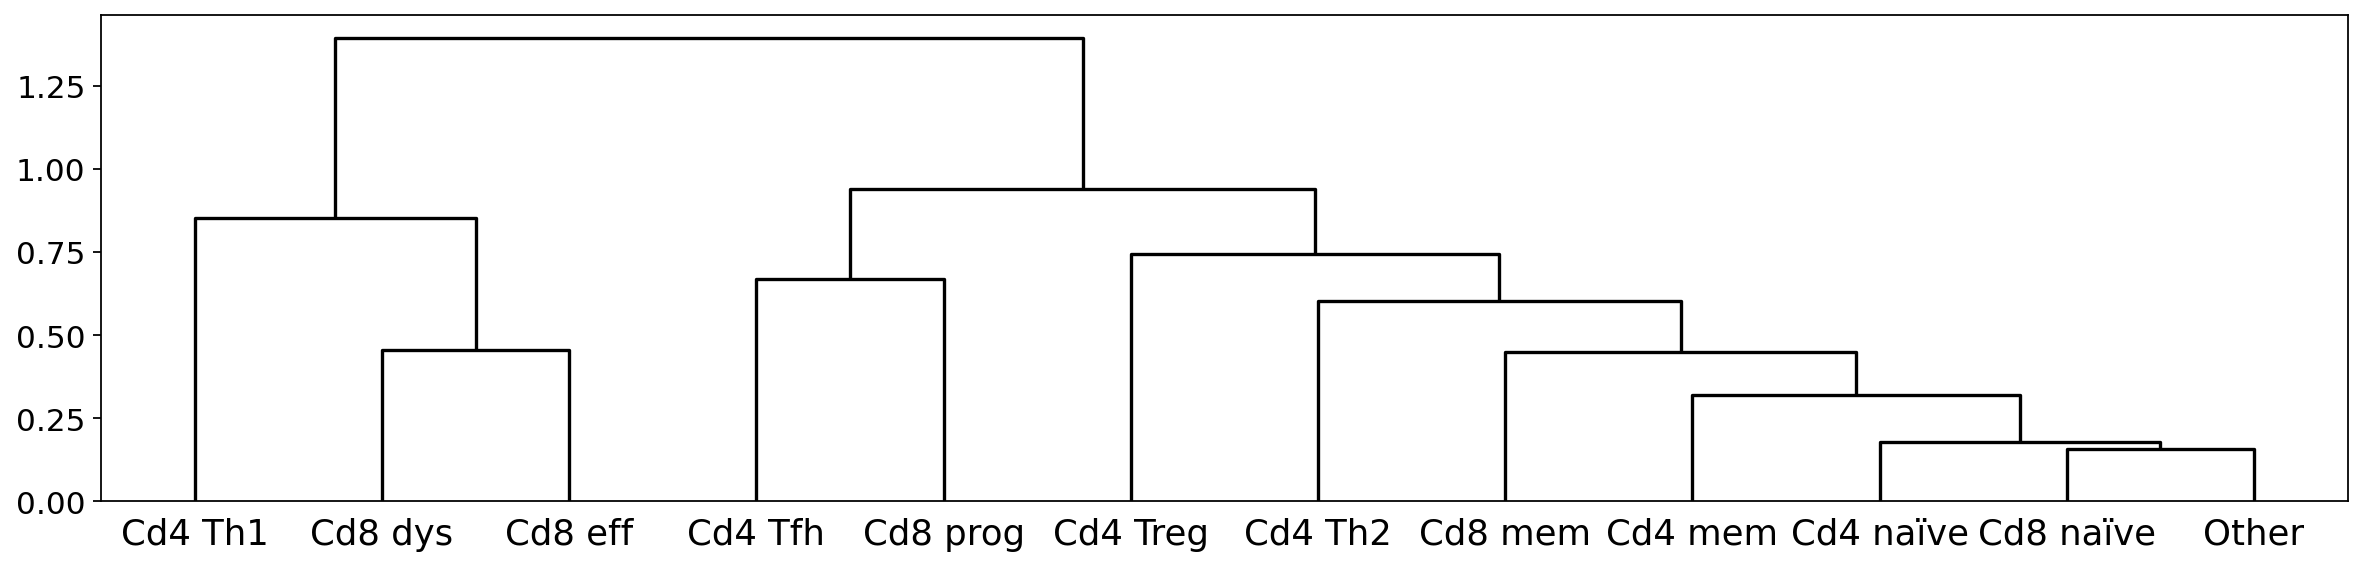

In [243]:
u.make_dendrogram(degs[(degs["log2FC"] > 1.5) & (degs["padj"] <= 0.05)].gene.unique(), rna,
                  lay = "theta_10", cluster_level = "final annotation", fig_size=(18, 4), 
                  out_name = "rna_dendrogram_3a.pdf")

In [244]:
daps = pd.read_csv("../bh_adjusted_daps.csv", index_col = 0)
daps

,log2FC,cluster_means,noncluster_means,pval,padj,gene,cluster
14047,4.666995,2204.91870,86.78866,4.086314e-01,4.373245e-01,peak.168551,Cd4 Tfh
24686,4.536339,5658.79100,243.86017,1.414230e-110,1.385753e-109,peak.24994,Cd4 Tfh
23991,4.343067,5748.94100,283.26114,7.555738e-165,1.247981e-163,peak.222075,Cd4 Tfh
23317,4.255544,2817.18750,147.48747,4.052116e-04,5.514730e-04,peak.216486,Cd4 Tfh
17689,4.142112,3318.64700,187.95335,2.938385e-69,1.847467e-68,peak.187564,Cd4 Tfh
...,...,...,...,...,...,...,...
19422,-1.786832,191.57993,661.07120,7.807019e-04,1.666538e-03,peak.216150,Other
1986,-1.834967,212.86660,759.44270,3.689984e-04,8.184749e-04,peak.111007,Other
30674,-1.930578,202.22327,770.90520,2.264034e-02,3.914799e-02,peak.87729,Other
19420,-1.950138,202.22327,781.42830,1.142744e-02,2.076471e-02,peak.216149,Other


In [256]:
peak_ad.layers

Layers with keys: fragment_counts, non_neg, pearson_norm, raw_counts

/Genomics/pritykinlab/sarah/lipstic_analysis/ulipstic-analysis/helper_functions_v2.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


(12, 4811)
(11, 4)


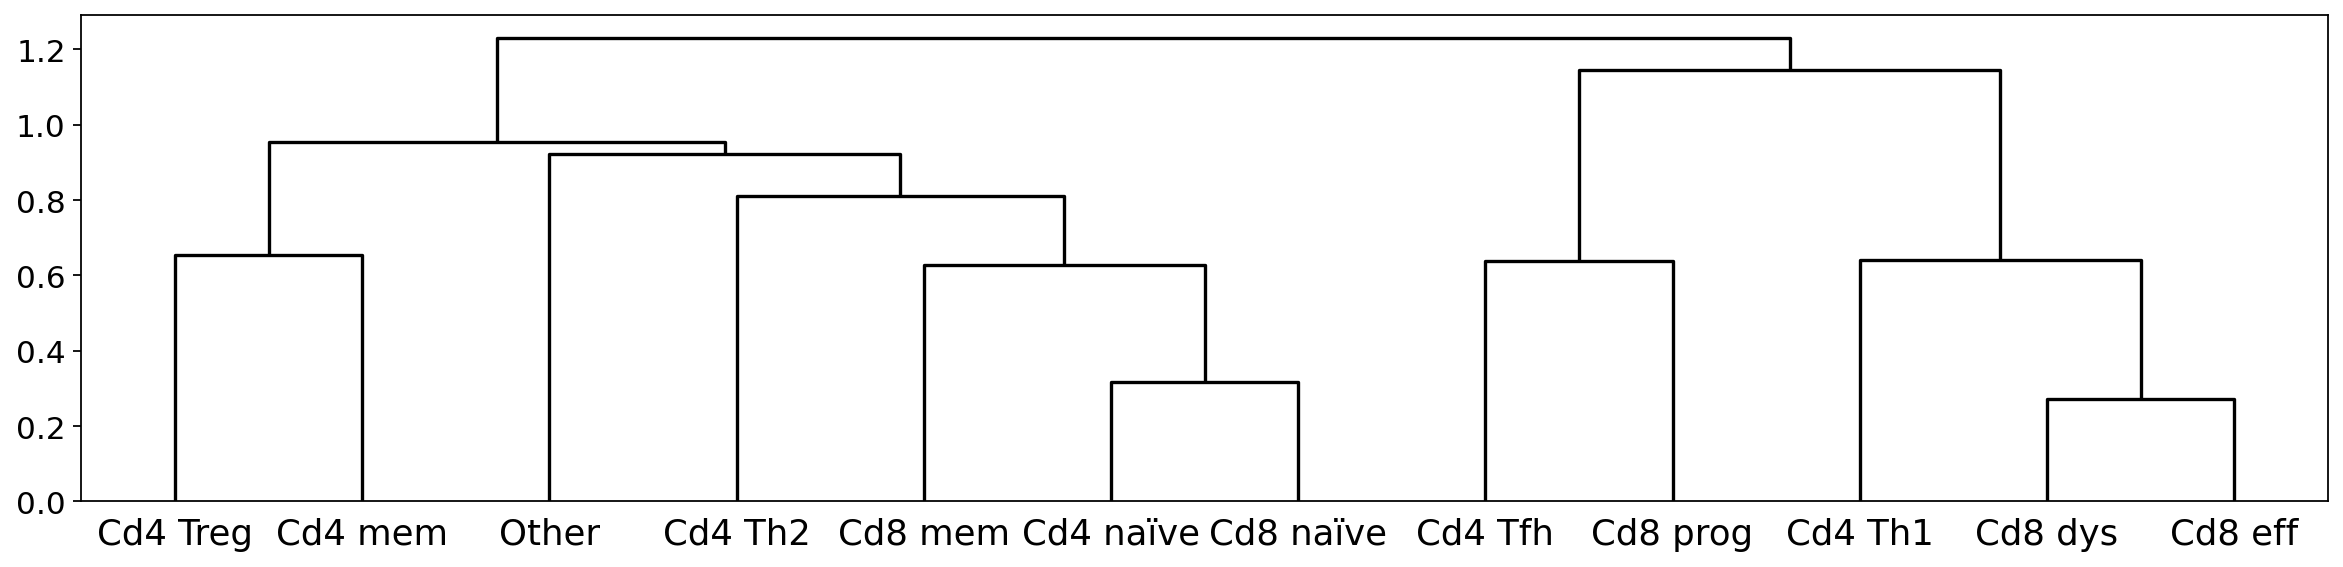

In [258]:
u.make_dendrogram(daps[(daps["log2FC"] > 1.5) & (daps["padj"] <= 0.05)].gene.unique(), peak_ad,
                  lay = "pearson_norm", cluster_level = "final annotation", fig_size=(18, 4), 
                  out_name = "atac_dendrogram_3a.pdf")

## supplemental panel 3A, left

/Genomics/pritykinlab/sarah/lipstic_analysis/ulipstic-analysis/helper_functions_v2.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


(12, 200769)
(11, 4)


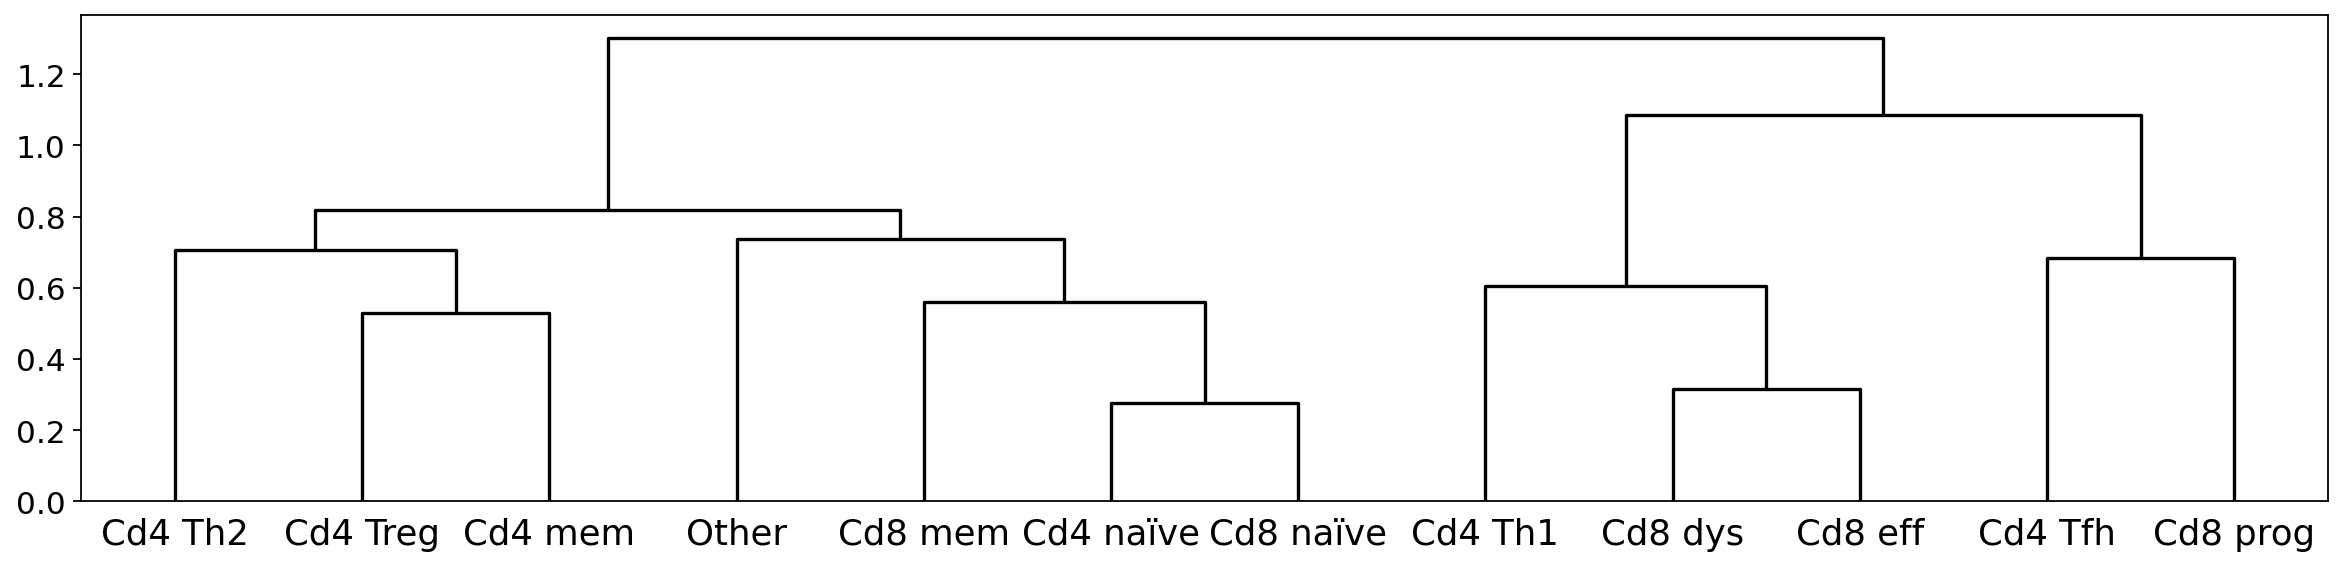

In [264]:
u.make_dendrogram(peak_ad.var_names, peak_ad, lay = "pearson_norm", cluster_level = "final annotation", 
                  fig_size=(18, 4))

/Genomics/pritykinlab/sarah/lipstic_analysis/ulipstic-analysis/helper_functions_v2.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


(12, 23958)
(11, 4)


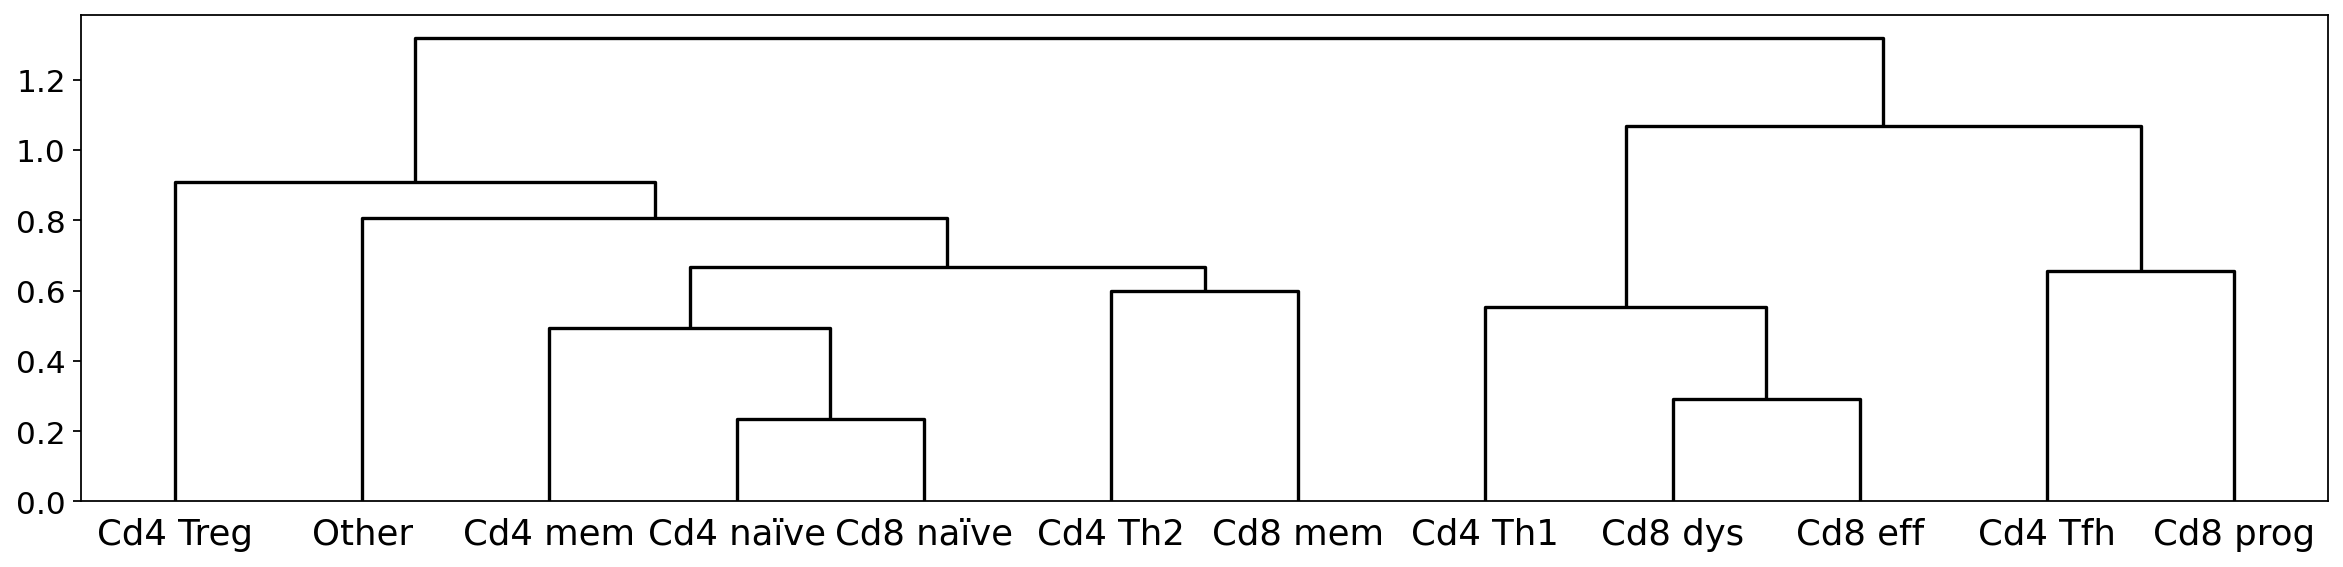

In [263]:
u.make_dendrogram(daps[(daps["log2FC"] > .5) & (daps["padj"] <= 0.05)].gene.unique(), peak_ad,
                  lay = "pearson_norm", cluster_level = "final annotation", fig_size=(18, 4))

/Genomics/pritykinlab/sarah/lipstic_analysis/ulipstic-analysis/helper_functions_v2.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


(12, 11550)
(11, 4)


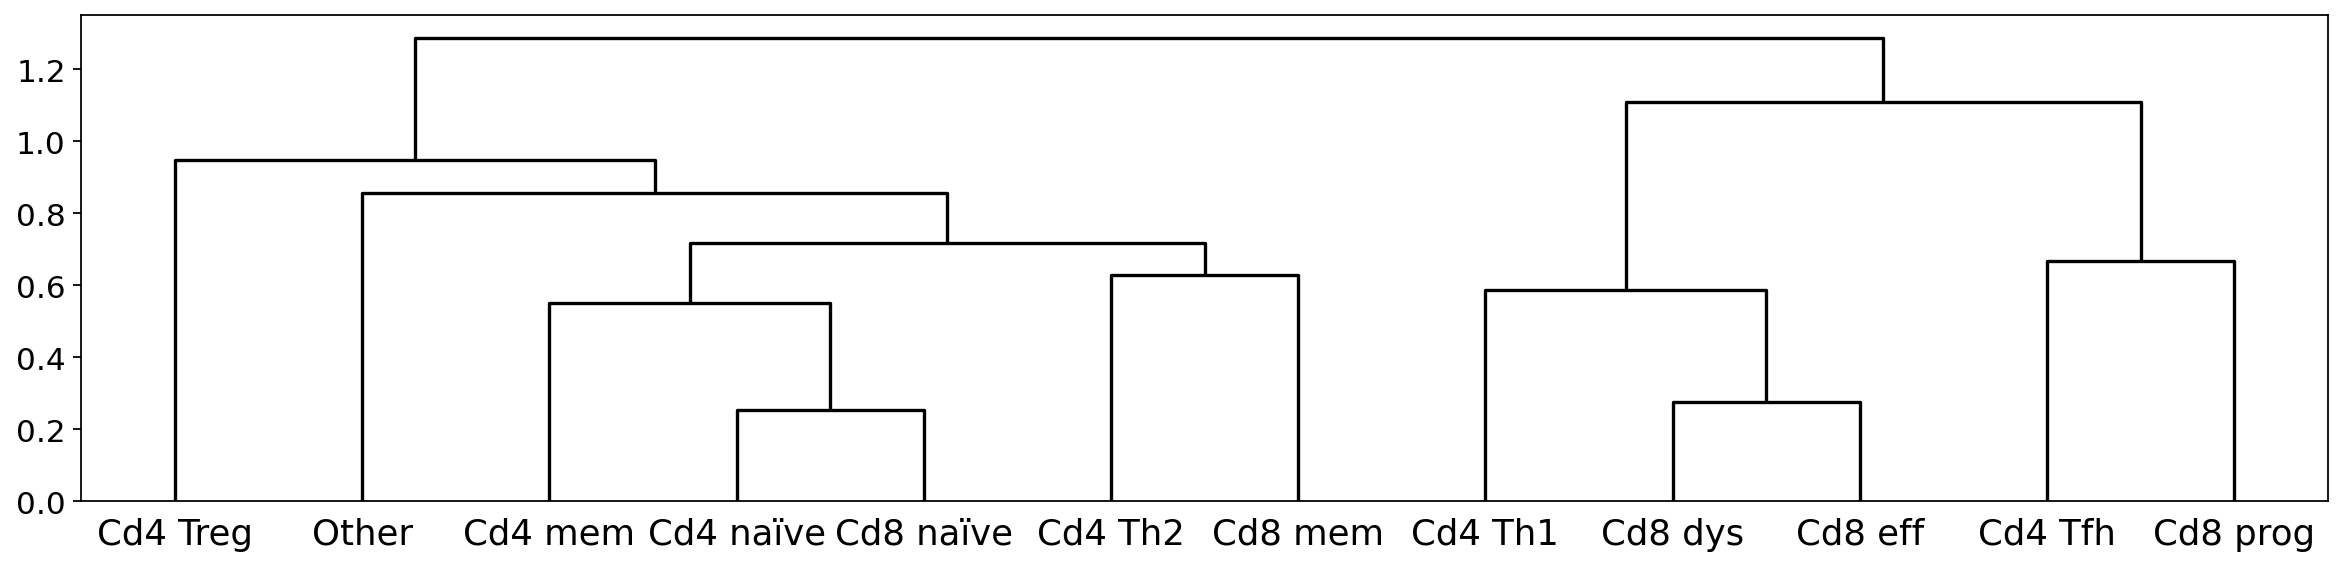

In [262]:
u.make_dendrogram(daps[(daps["log2FC"] > 1.) & (daps["padj"] <= 0.05)].gene.unique(), peak_ad,
                  lay = "pearson_norm", cluster_level = "final annotation", fig_size=(18, 4))

## supplemental panel 3A, right

/Genomics/pritykinlab/sarah/lipstic_analysis/ulipstic-analysis/helper_functions_v2.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


(12, 15397)
(11, 4)


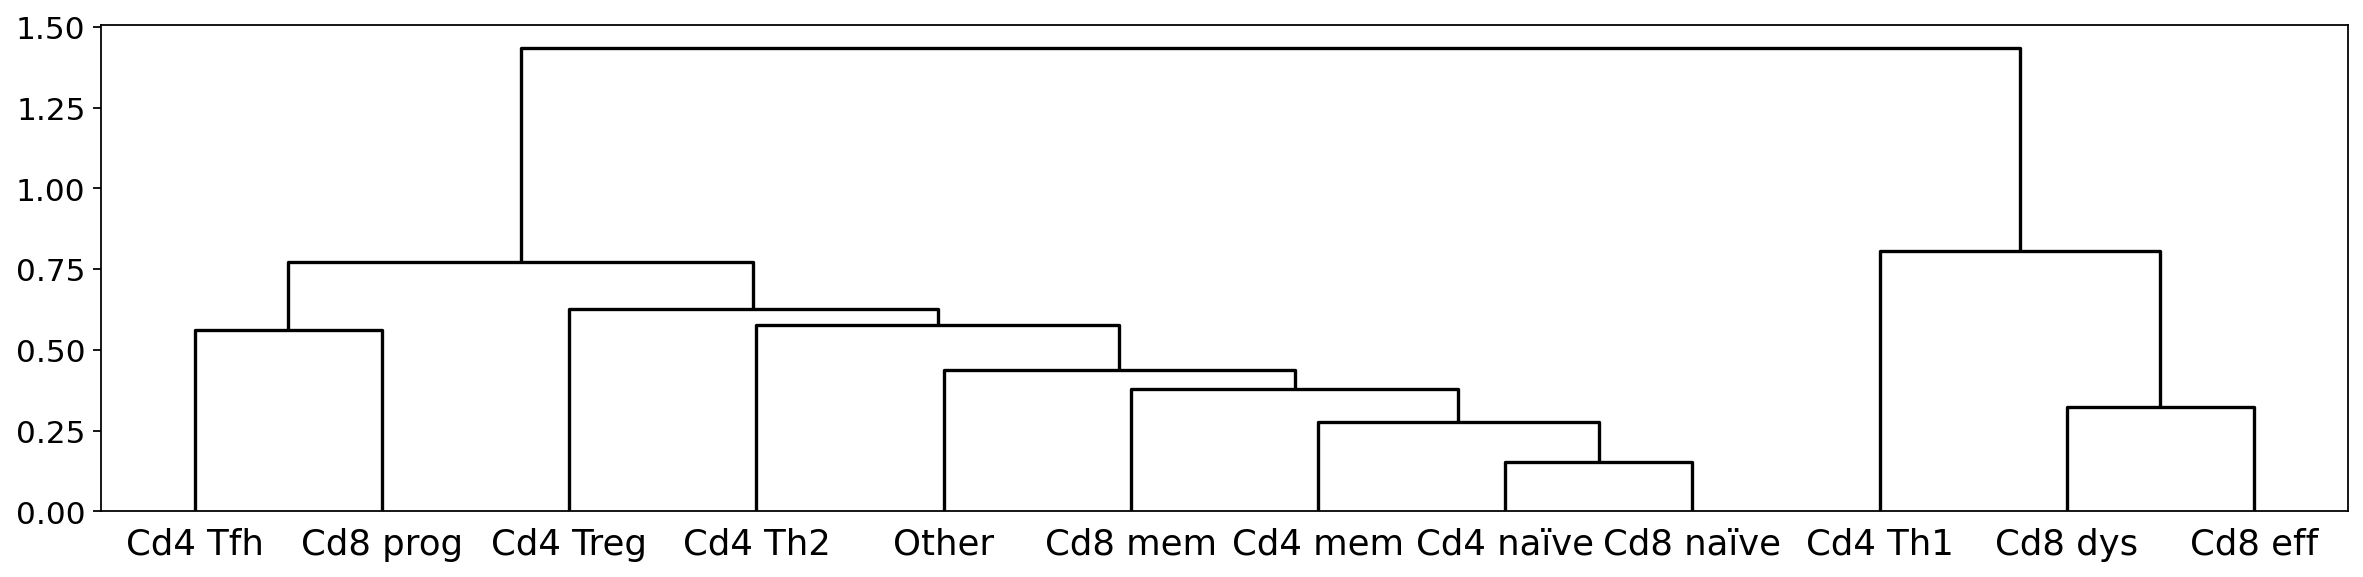

In [259]:
u.make_dendrogram(rna.var_names, rna, lay = "theta_10", cluster_level = "final annotation", fig_size=(18, 4))

/Genomics/pritykinlab/sarah/lipstic_analysis/ulipstic-analysis/helper_functions_v2.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


(12, 2619)
(11, 4)


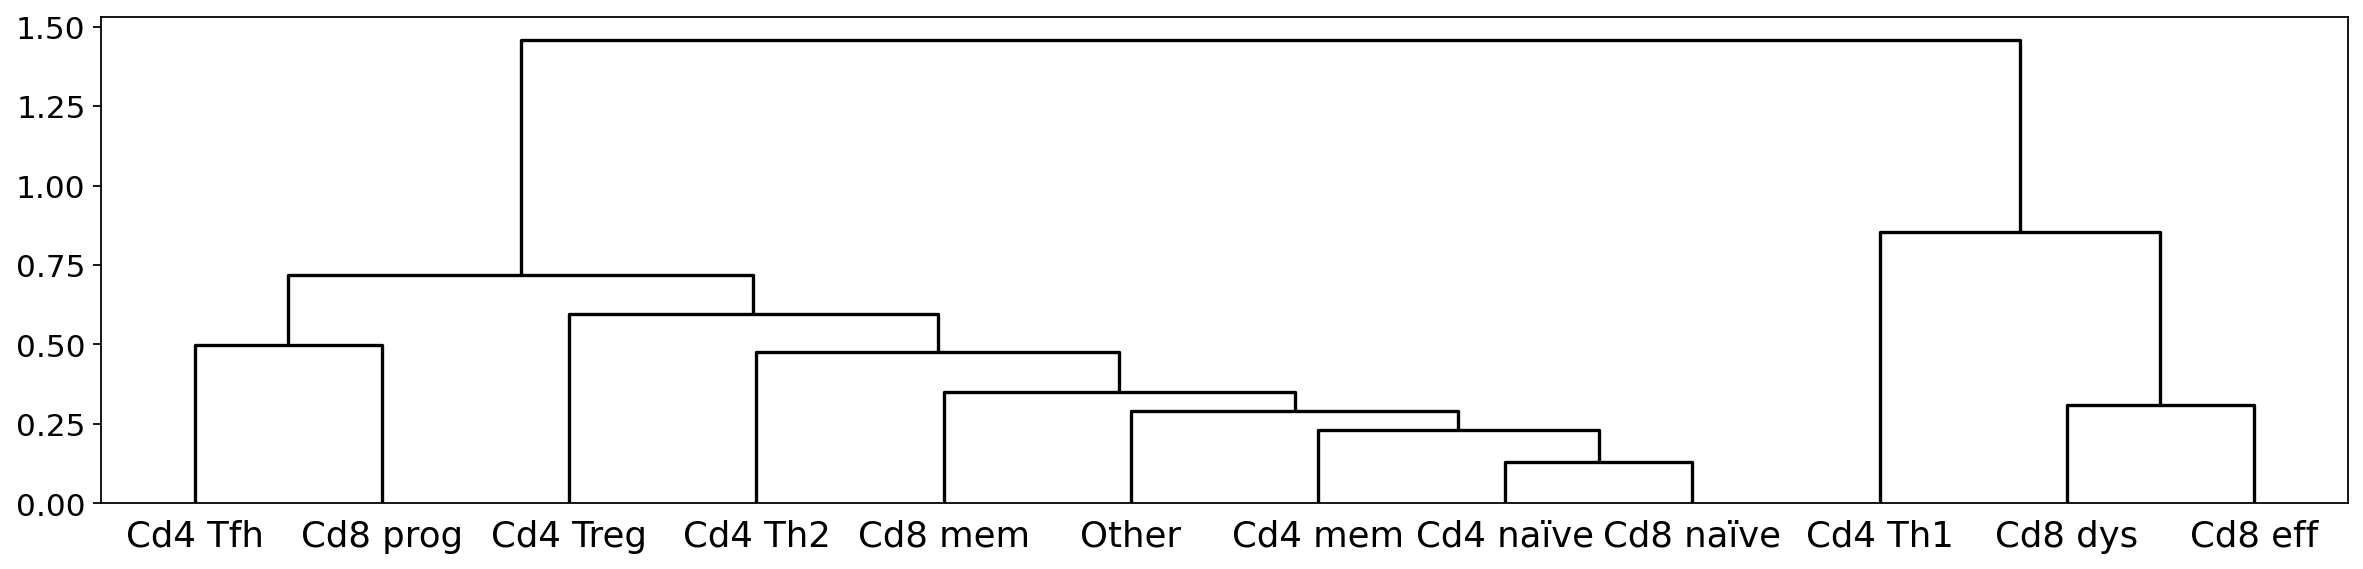

In [260]:
u.make_dendrogram(degs[(degs["log2FC"] > 0.5) & (degs["padj"] <= 0.05)].gene.unique(), rna,
                  lay = "theta_10", cluster_level = "final annotation", fig_size=(18, 4))

/Genomics/pritykinlab/sarah/lipstic_analysis/ulipstic-analysis/helper_functions_v2.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


(12, 858)
(11, 4)


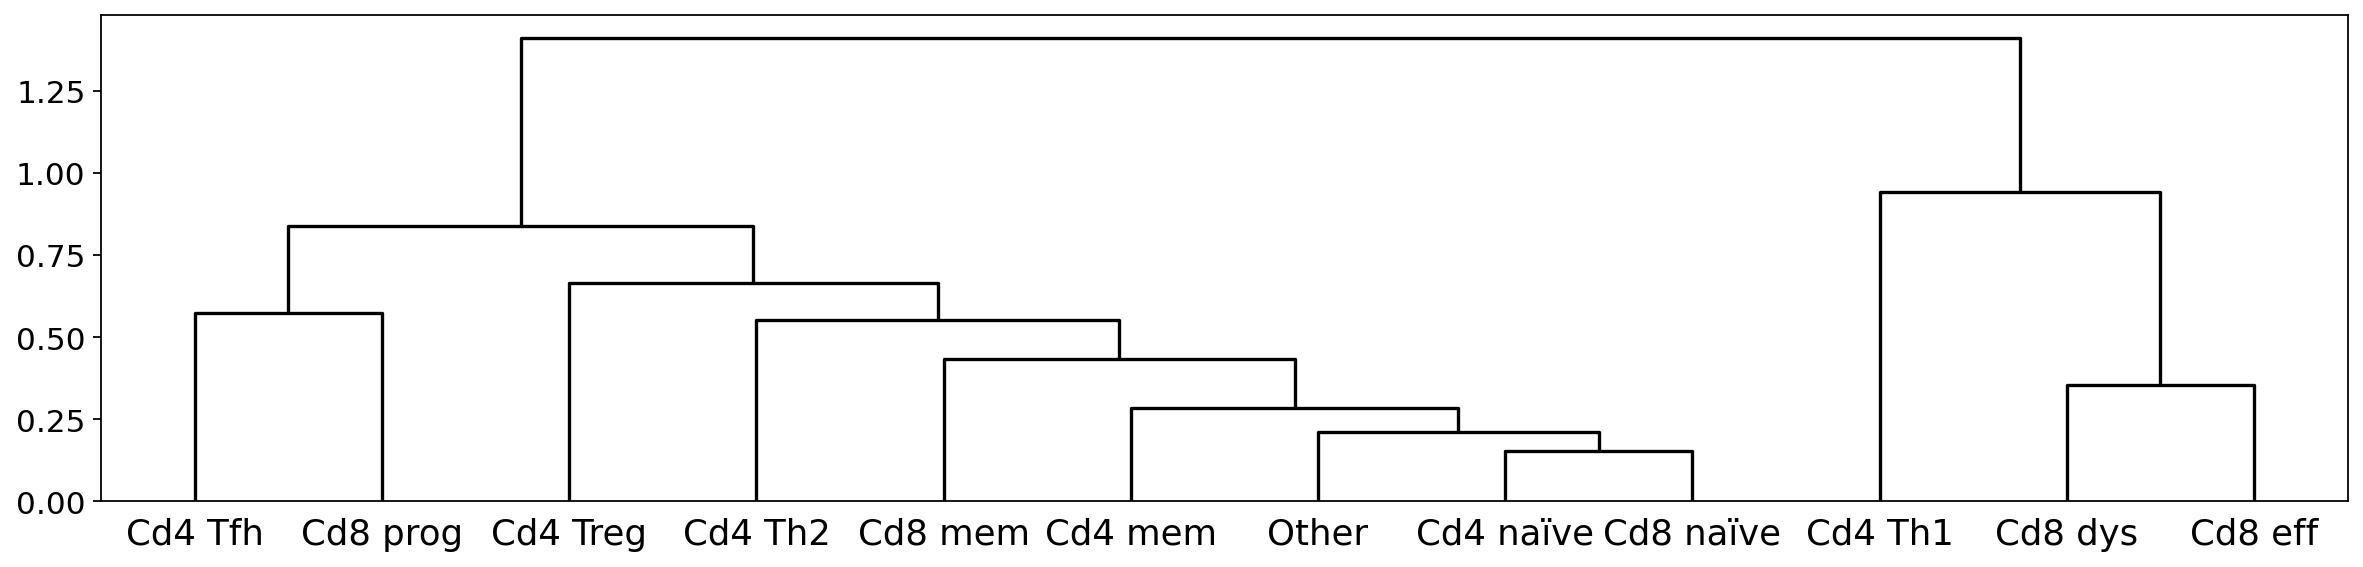

In [261]:
u.make_dendrogram(degs[(degs["log2FC"] > 1.) & (degs["padj"] <= 0.05)].gene.unique(), rna,
                  lay = "theta_10", cluster_level = "final annotation", fig_size=(18, 4))

## panel B

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

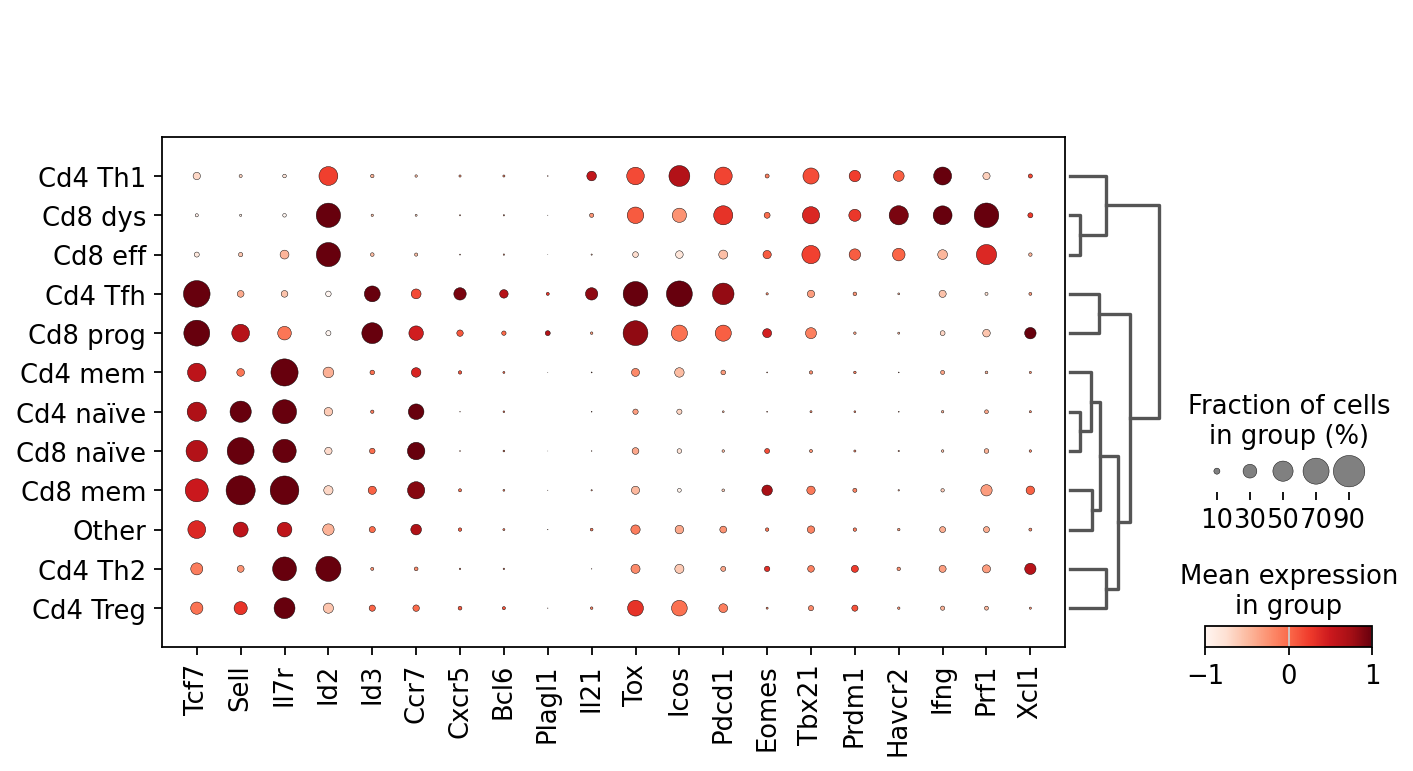

In [10]:
sc.pl.dotplot(rna, groupby = "final annotation", 
              var_names = ["Tcf7", "Sell", "Il7r", "Id2", "Id3", "Ccr7",  # mem like
                           "Cxcr5", "Bcl6",  "Plagl1","Il21", 
                            "Tox", "Icos", "Pdcd1",
                            "Eomes", 
                           "Tbx21", 
                           "Prdm1","Havcr2",
                           "Ifng", "Prf1",   
                           "Xcl1"], dendrogram= True, norm = Normalize(-1,1)) # , save = "3d_all.pdf")

## panel C is a cartoon made with BioRender and edited in Illustrator 

## panel D

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored


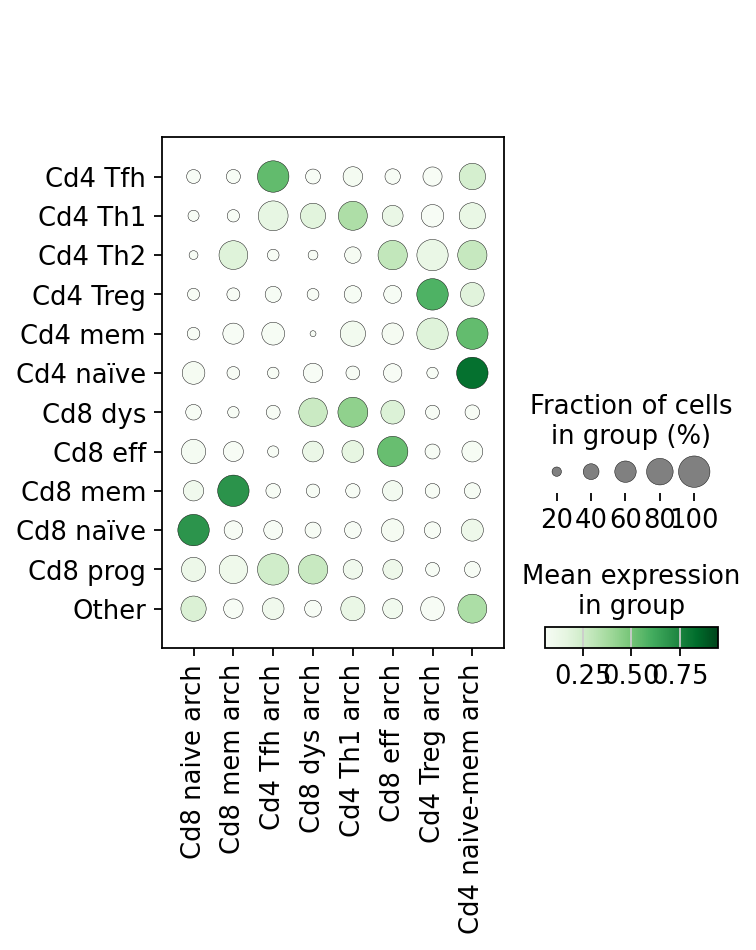

In [11]:
sc.pl.dotplot(peak_ad, groupby = "final annotation", var_names = list(archetype_naming.values()),
             cmap = "Greens", vmax = 0.95, vmin = 0.05, save = "3d_all.pdf")

## supplementary figure panel B

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored


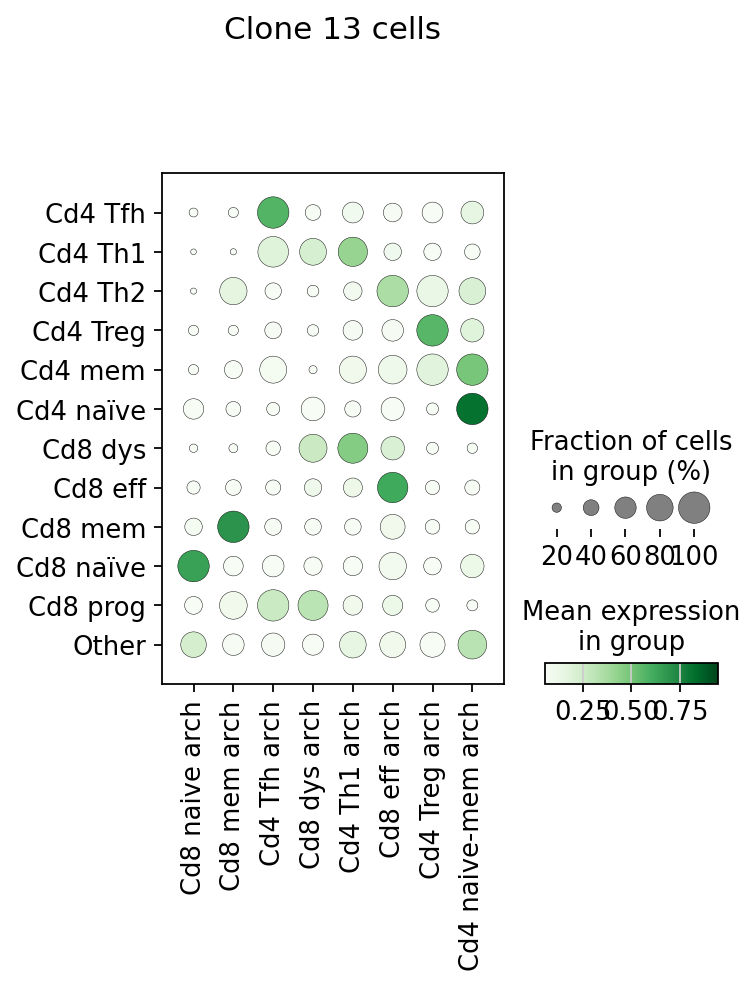

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored


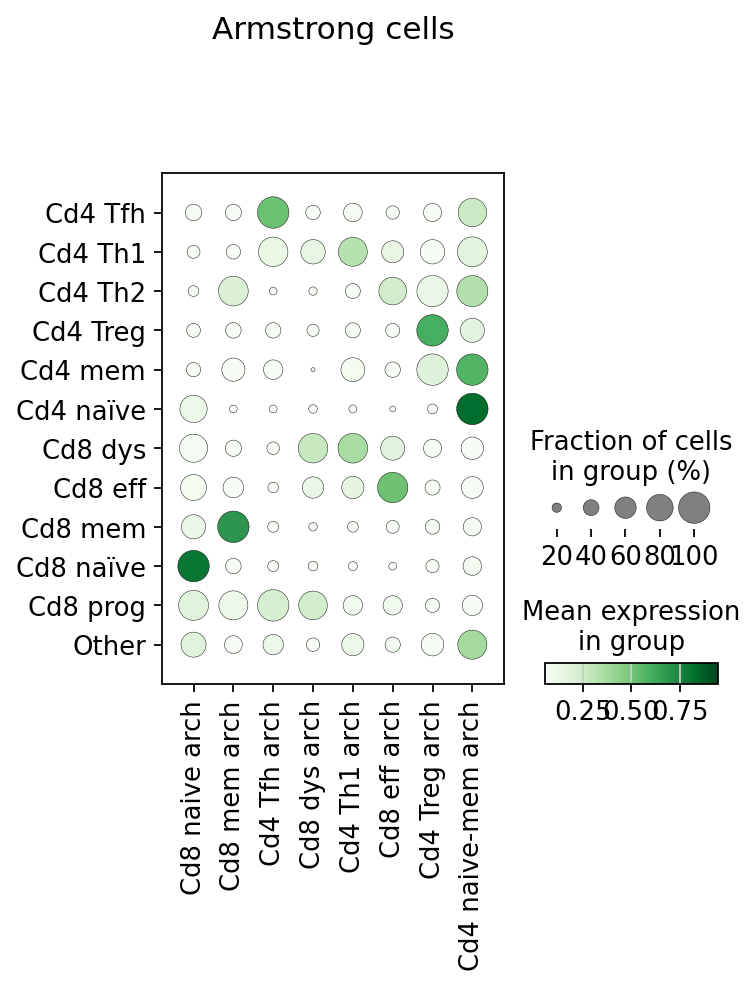

In [12]:
sc.pl.dotplot(peak_ad[peak_ad.obs["sample"] == "cl13"], groupby = "final annotation", var_names = list(
    archetype_naming.values()), cmap = "Greens", vmax = 0.95, vmin = 0.05, title = "Clone 13 cells",
              save = "3d_cl13.png")
sc.pl.dotplot(peak_ad[peak_ad.obs["sample"] == "arm"], groupby = "final annotation", var_names = list(
    archetype_naming.values()), cmap = "Greens", vmax = 0.95, vmin = 0.05, title = "Armstrong cells",
              save = "3d_arm.png")

## supplementary panel C

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored


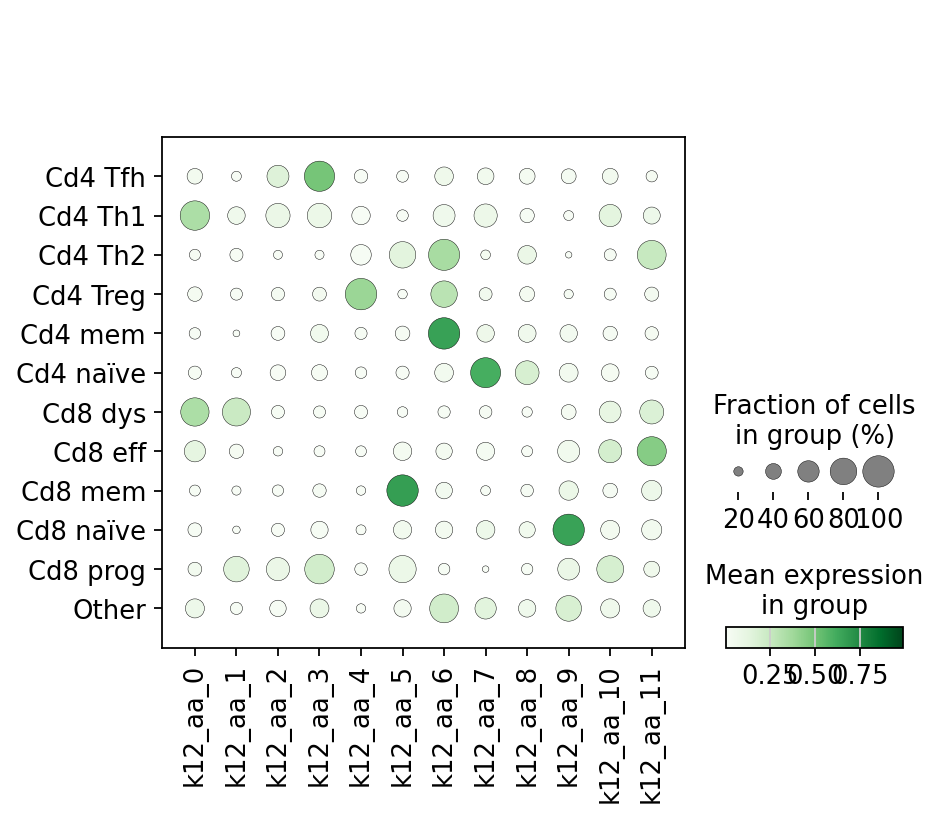

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored


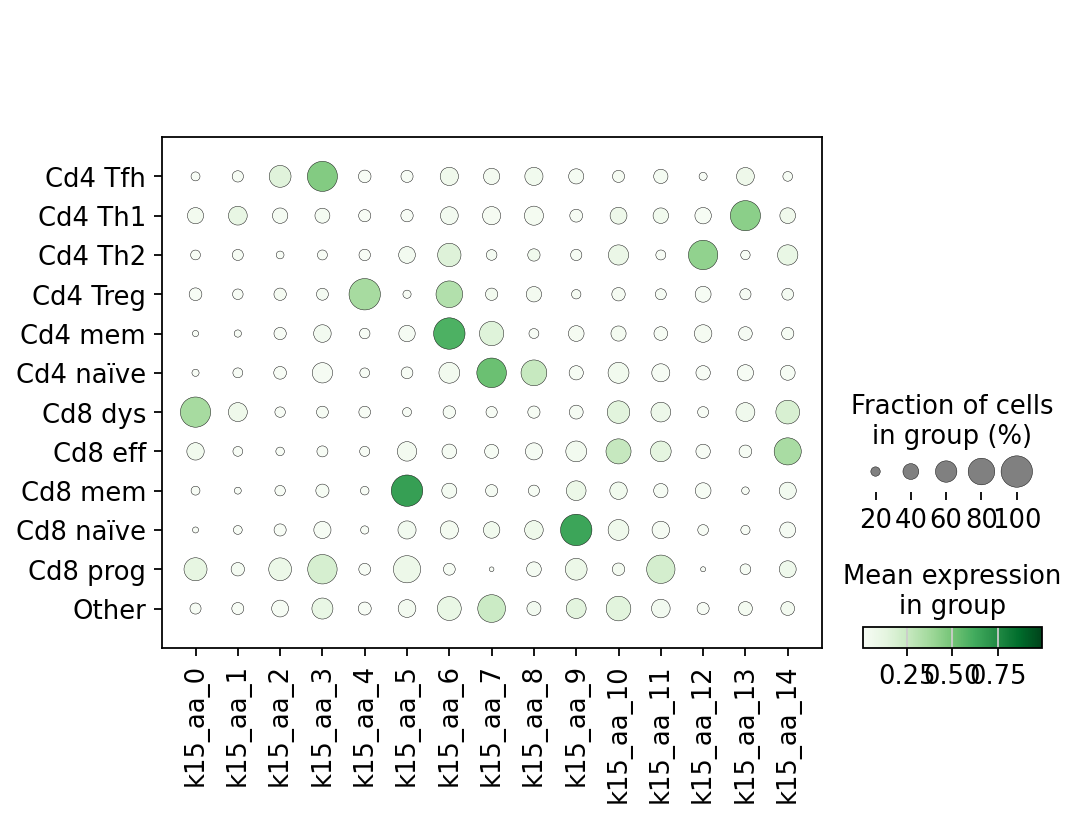

In [56]:
sc.pl.dotplot(peak_ad, groupby = "final annotation", var_names = ["k12_aa_%s"%i for i in range(12)], 
              cmap = "Greens", vmax = 0.99, vmin = 0.01, save = "k12_aa.png")
sc.pl.dotplot(peak_ad, groupby = "final annotation", var_names = ["k15_aa_%s"%i for i in range(15)], 
              cmap = "Greens", vmax = 0.99, vmin = 0.01, save = "k15_aa.png")

In [83]:
k12_archs = pd.read_csv("../aa_outs/k12_archetypes.csv", index_col = 0)
k8_archs = pd.read_csv("../aa_outs/k8_archetypes.csv", index_col = 0)
k15_archs = pd.read_csv("../aa_outs/k15_archetypes.csv", index_col = 0)

In [84]:
k12_archs.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-0.040157,-0.022073,-0.014087,-0.043933,-0.052978,-0.055543,-0.036392,0.090461,0.476256,0.042511,-0.057313,-0.038290
1,0.033273,0.332204,0.026034,-0.140885,-0.119536,0.175619,-0.062917,-0.226398,-0.270928,-0.251016,0.370832,0.191117
2,0.051615,0.183586,0.058048,-0.088874,-0.087803,0.086226,-0.033125,-0.092487,-0.104530,-0.105463,0.224765,0.039272
3,-0.002830,0.054792,0.106942,-0.079897,-0.007573,0.103666,-0.017162,-0.060310,-0.092950,-0.076963,0.113867,0.048952
4,-0.001199,0.156480,0.009521,-0.095975,-0.026001,0.167161,-0.041582,-0.109591,-0.112497,-0.107582,0.087506,0.025546


In [95]:
def make_corrs(df):
    test_archs = pd.DataFrame({"a1": a1, "a2": a2, "corr": spearmanr(df[a1], df[a2])[0]}
                              for a1,a2 in combinations(df.columns, 2))
    test_archs = pd.concat([test_archs, test_archs.rename(columns = {"a1": "a2", "a2": "a1"})])
    test_archs["c"] = np.round(test_archs["corr"], 2)
    return ggplot(test_archs, aes(x="a1", y="a2", fill = "corr", label = "c")) + geom_bin2d() + theme(
        figure_size=(10, 8)) + geom_text()

## supplementary figure D

/tmp/ipykernel_4057111/651818114.py:2: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


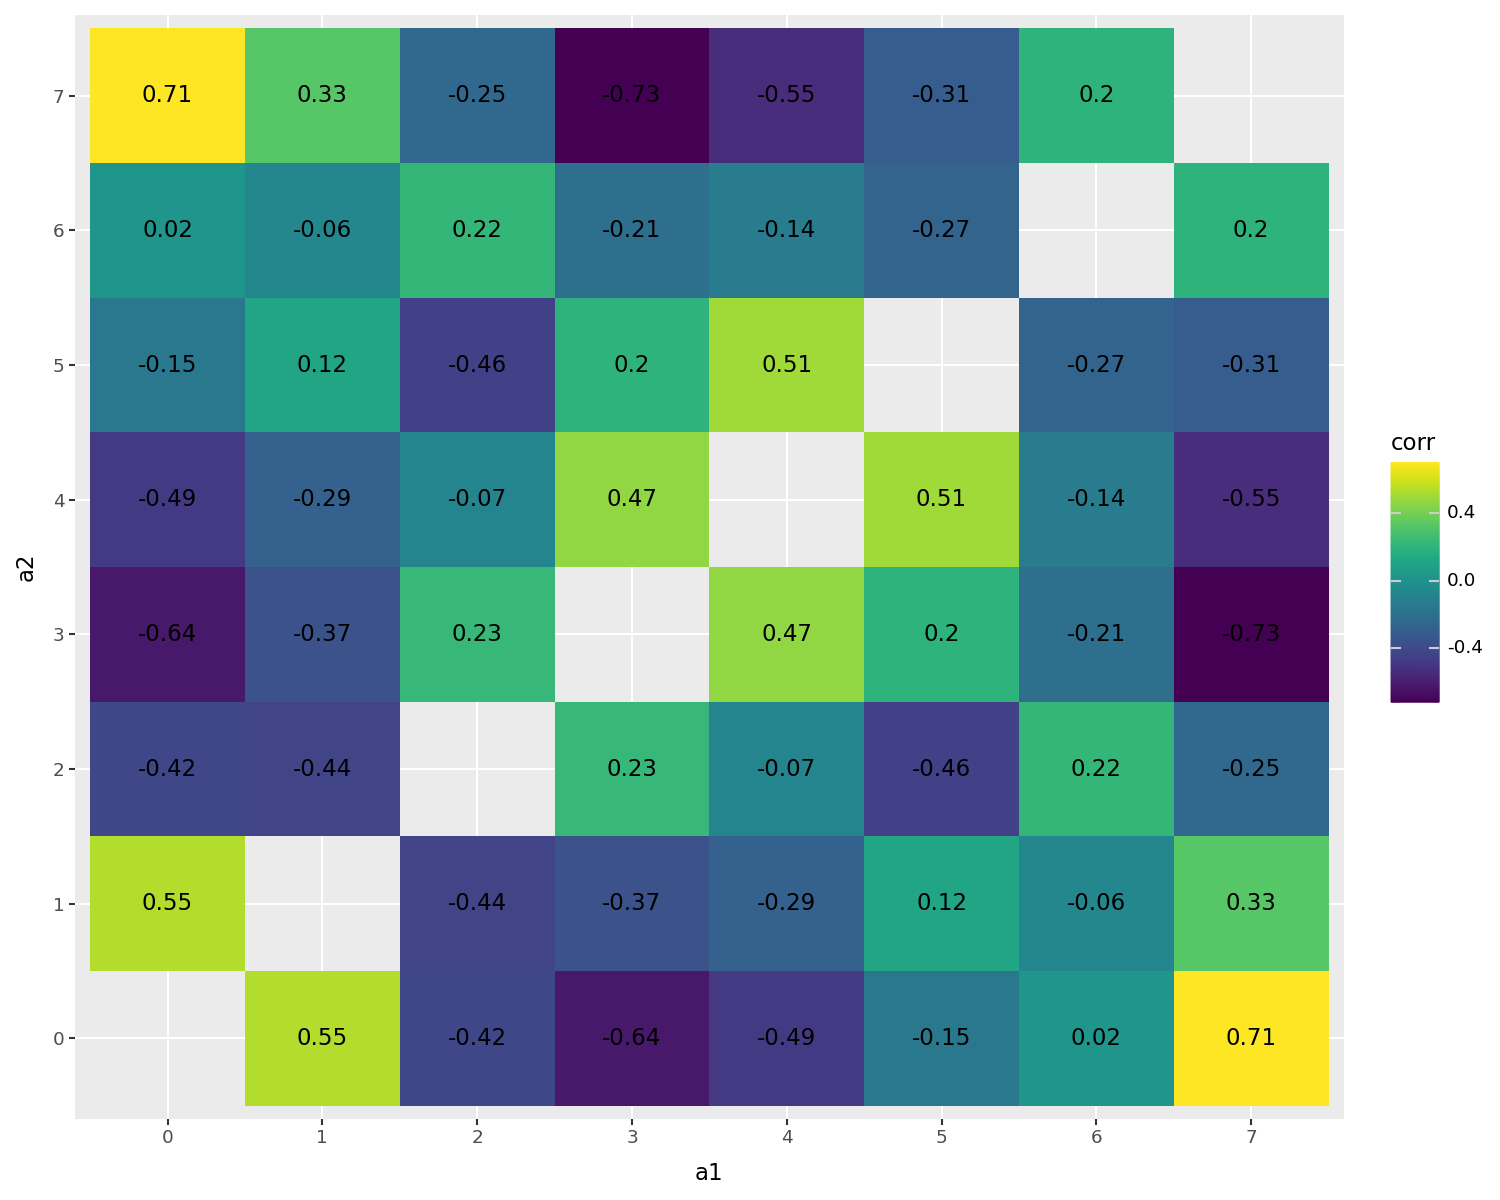

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 10 x 8 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/s4_k8.png


In [98]:
k8_c_plot = make_corrs(k8_archs)
print(k8_c_plot)
ggsave(k8_c_plot, "figures/s4_k8.png")

/tmp/ipykernel_4057111/1212635399.py:2: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


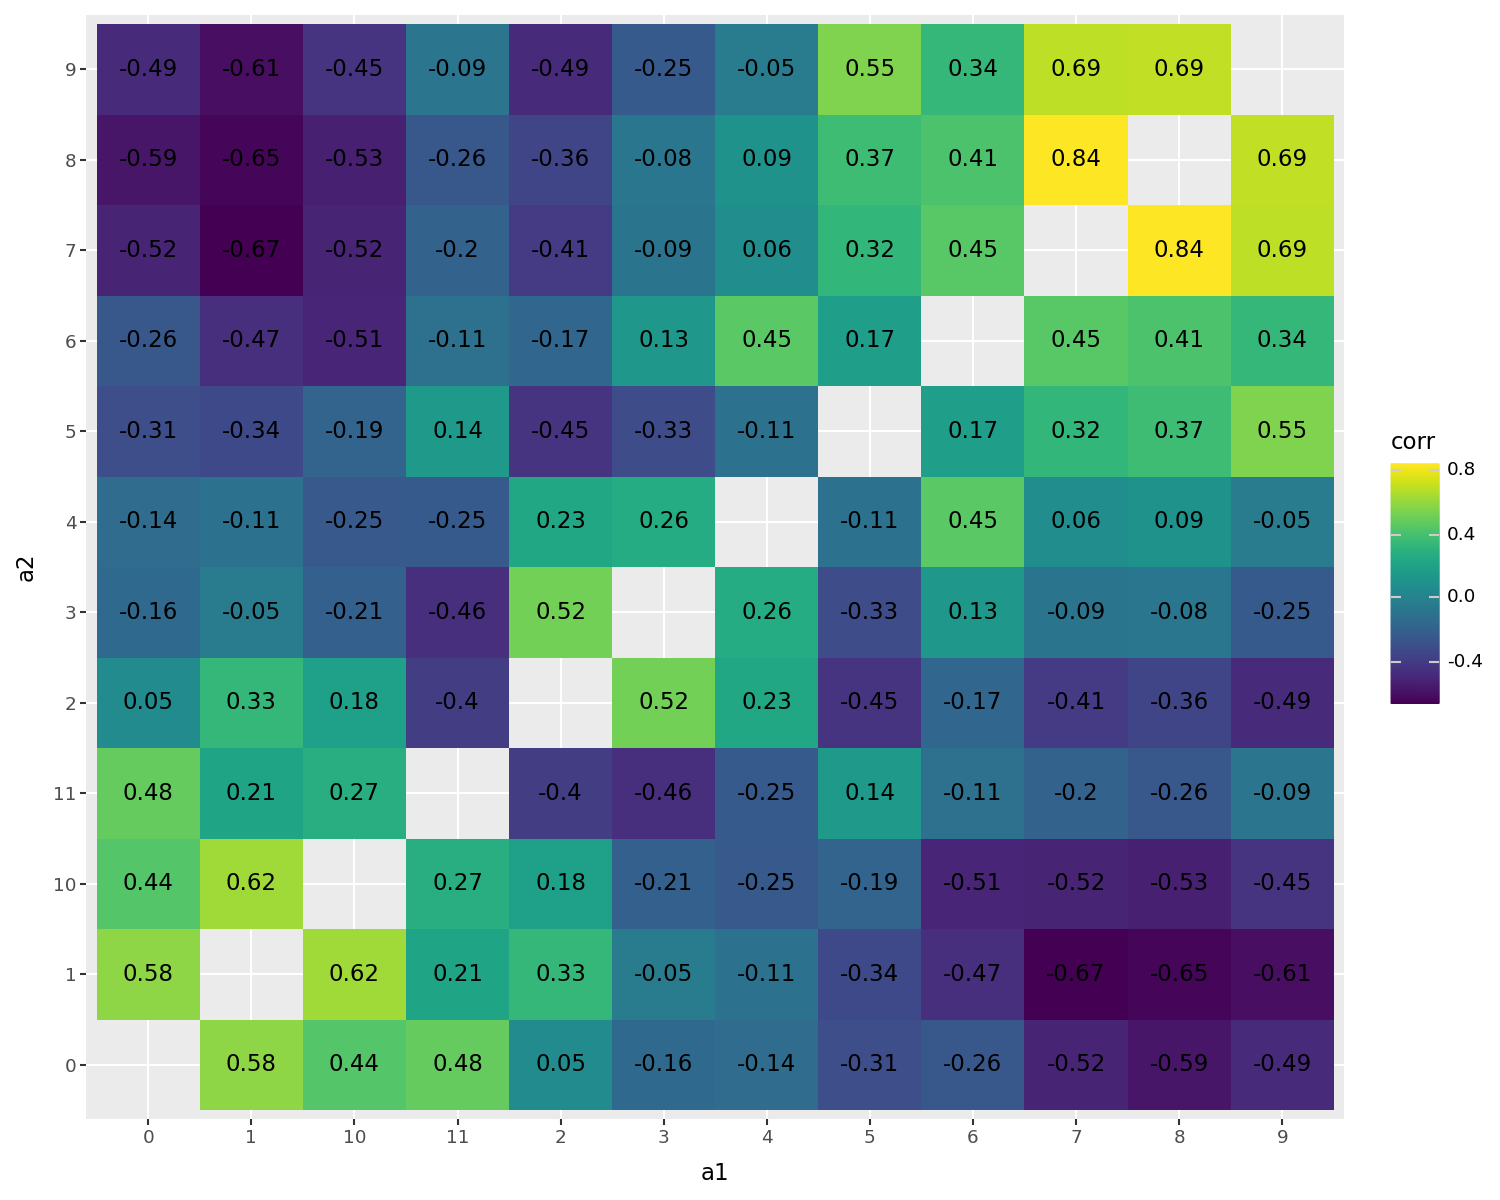

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 10 x 8 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/s4_k12.png


In [97]:
k12_c_plot = make_corrs(k12_archs)
print(k12_c_plot)
ggsave(k12_c_plot, "figures/s4_k12.png")

/tmp/ipykernel_4057111/2151333360.py:2: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


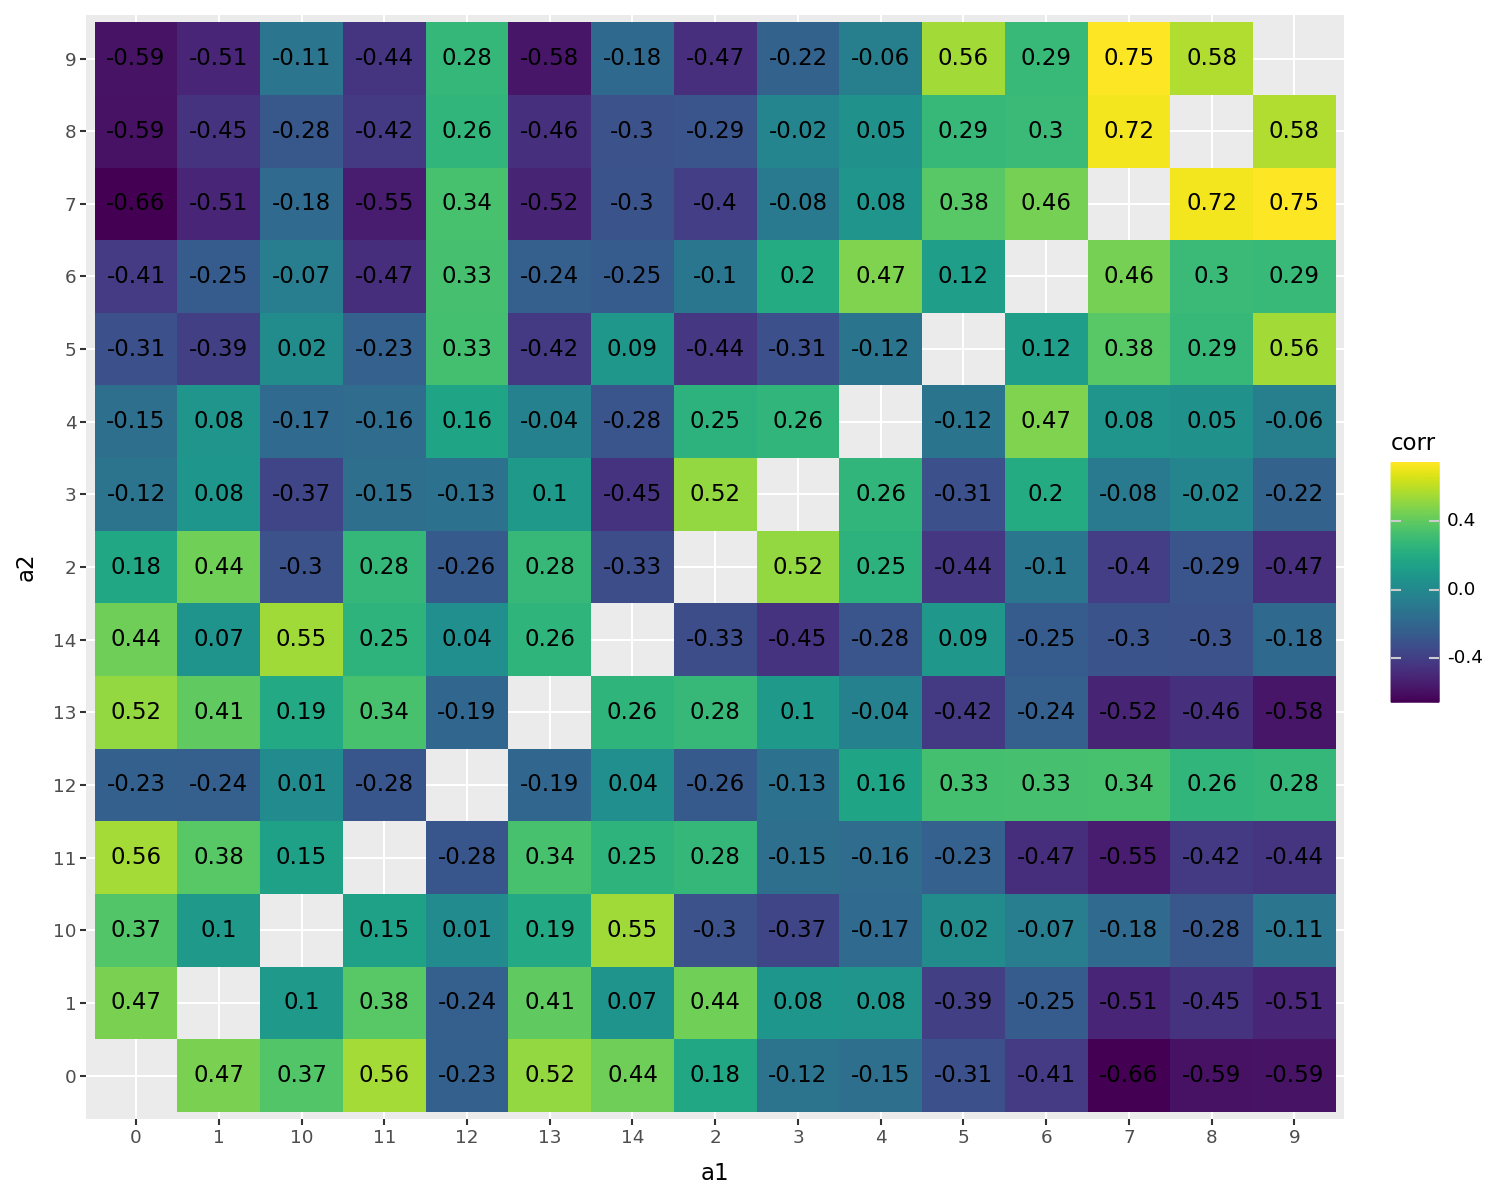

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 10 x 8 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/s4_k15.png


In [96]:
k15_c_plot = make_corrs(k15_archs)
print(k15_c_plot)
ggsave(k15_c_plot, "figures/s4_k15.png")

## supplementary panel E

In [99]:
def make_pairwise_corrs(df1, df2):
    test_archs = pd.DataFrame({"a1": a1, "a2": a2, "corr": spearmanr(df1[a1], df2[a2])[0]}
                              for a1 in df1.columns for a2 in df2.columns)
    # test_archs = pd.concat([test_archs, test_archs.rename(columns = {"a1": "a2", "a2": "a1"})])
    test_archs["c"] = np.round(test_archs["corr"], 2)
    return ggplot(test_archs, aes(x="a1", y="a2", fill = "corr", label = "c")) + geom_bin2d() + theme(
        figure_size=(10, 8)) + geom_text()

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 10 x 8 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/s4_k8_k12.png


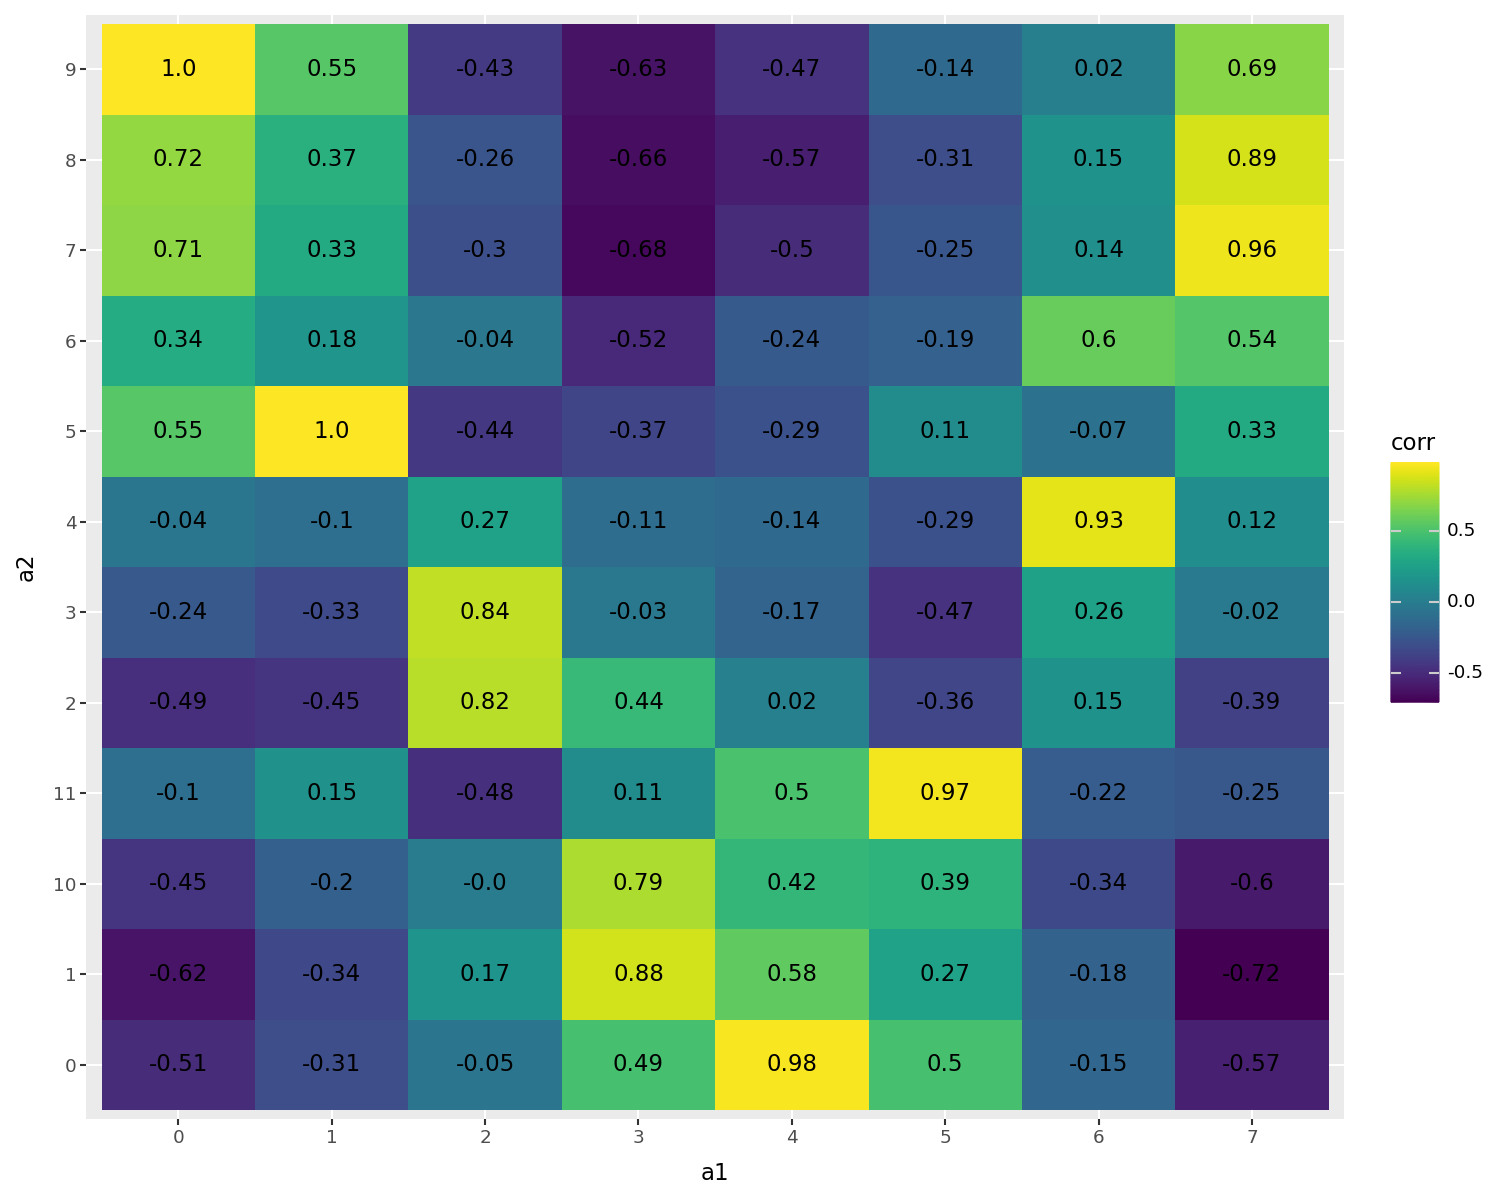

In [102]:
k8_vs_k12 = make_pairwise_corrs(k8_archs, k12_archs)
ggsave(k8_vs_k12, "figures/s4_k8_k12.png")
k8_vs_k12

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 10 x 8 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/s4_k8_k15.png


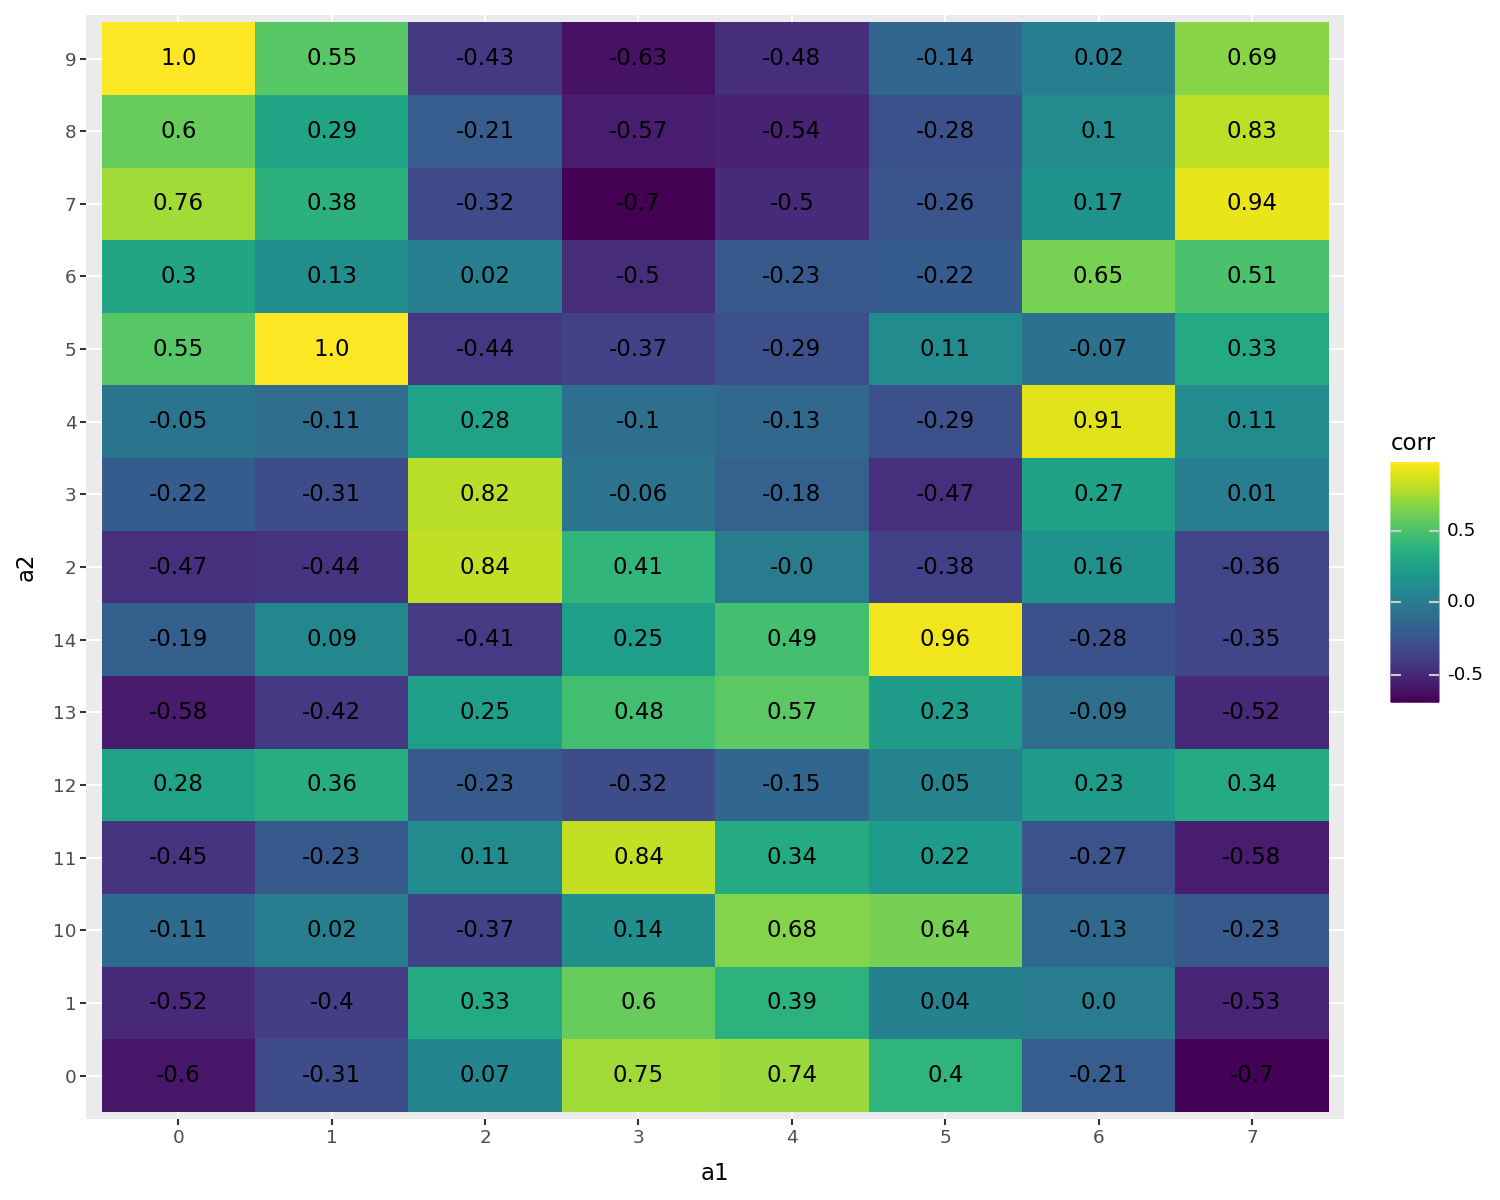

In [101]:
k8_vs_k15 = make_pairwise_corrs(k8_archs, k15_archs)
ggsave(k8_vs_k15, "figures/s4_k8_k15.png")
k8_vs_k15

## bar plot (main panel E)

In [103]:
gene_peaks = {"Il4": "peak.135607", 
              "Foxp3": "peak.216731", 
              "Cd8a": "peak.76564",
              "Cd4": "peak.81202", 
              "Sell": "peak.12434", 
              "Tcf7": "peak.135437",
              "Ifngr2": "peak.192627", 
              "Cxcr5": "peak.110120", 
              "Ifng": "peak.129731", 
              "Tox": "peak.44931", 
              "Pdcd1": "peak.7183", 
              "Cx3cr1": "peak.118153" , 
              "Slamf6": "peak.13351"}

In [105]:
archs = pd.read_csv("../aa_outs/k8_archetypes.csv", index_col=0, names=list(archetype_naming.values()),
                   header=0)
archs.head()

,Cd8 naive arch,Cd8 mem arch,Cd4 Tfh arch,Cd8 dys arch,Cd4 Th1 arch,Cd8 eff arch,Cd4 Treg arch,Cd4 naive-mem arch
0,0.062323,-0.055760,-0.024836,-0.053871,-0.040937,-0.034275,-0.014452,0.145732
1,-0.256363,0.183456,-0.107449,0.432044,0.024806,0.239918,-0.136494,-0.226018
2,-0.109784,0.095190,-0.041377,0.246783,0.046414,0.044093,-0.076328,-0.103307
3,-0.077649,0.102692,-0.012406,0.100834,-0.008676,0.058237,0.005486,-0.049818
4,-0.107604,0.168230,-0.057764,0.118743,0.017926,0.041070,-0.055146,-0.109945


In [106]:
archs.index = peak_ad.var_names
archs["gene"] = list(peak_ad.var["gene"])

In [107]:
interesting_arch_peaks = archs[archs["gene"].isin(gene_peaks.keys())]
top_arch_per_peak = pd.DataFrame(interesting_arch_peaks.drop(columns = "gene").idxmax(1), columns = ["arch"])
top_arch_per_peak

,arch
peak.110117,Cd4 Treg arch
peak.110118,Cd8 mem arch
peak.110119,Cd8 mem arch
peak.110120,Cd4 Tfh arch
peak.110121,Cd4 Tfh arch
...,...
peak.81203,Cd4 naive-mem arch
peak.81204,Cd4 naive-mem arch
peak.81205,Cd4 naive-mem arch
peak.81206,Cd8 dys arch


In [108]:
top_arch_per_peak = top_arch_per_peak.merge(interesting_arch_peaks[["gene"]], left_index = True, right_index = True)

In [109]:
arch_colors = {"Cd8 naive arch": "#3E7958",
               "Cd8 mem arch": "#A4CCB4",
               "Cd4 Tfh arch": "#C4AF9A",
               "Cd8 dys arch": "#2B3A67",
               "Cd4 Th1 arch": "#D58696",
               "Cd8 eff arch": "#73ACBF",
               "Cd4 Treg arch": "#FFDE70",
               "Cd4 naive-mem arch": "#C85919"}

In [110]:
arch_bars = ggplot(top_arch_per_peak, aes(x="gene", fill = "arch")) + geom_bar(position = "fill") + theme_tufte() + \
theme(dpi = 200, figure_size=(10, 6)) + geom_text(interesting_arch_peaks.groupby("gene").count().reset_index(), 
                                                  aes(x="gene", label = "Cd8 naive arch"), y=1, color = "black",
                                                  inherit_aes = False) + scale_fill_manual(arch_colors)

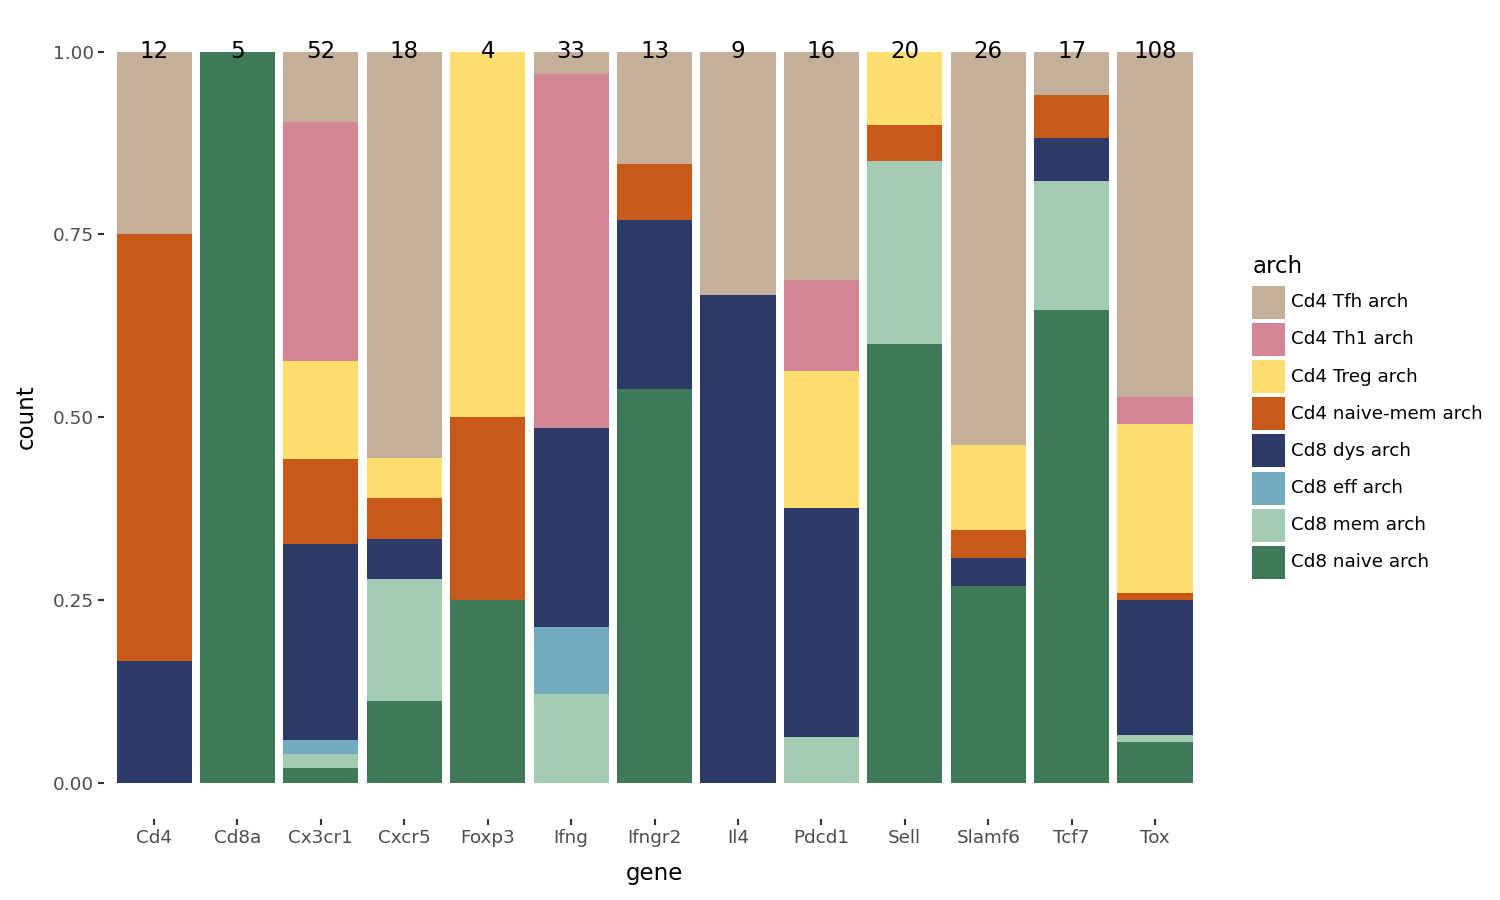

In [111]:
arch_bars

In [112]:
ggsave(arch_bars, dpi = 200, filename="figures/3e_barplot.pdf")

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 10 x 6 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/3e_barplot.pdf


## panel F

In [114]:
from scipy.stats import zscore
zscored_peaks = zscore(peak_ad.layers["pearson_norm"], axis = 1)

In [115]:
archs.index = peak_ad.var_names
archs.head()

,Cd8 naive arch,Cd8 mem arch,Cd4 Tfh arch,Cd8 dys arch,Cd4 Th1 arch,Cd8 eff arch,Cd4 Treg arch,Cd4 naive-mem arch,gene
peak.10000,0.062323,-0.055760,-0.024836,-0.053871,-0.040937,-0.034275,-0.014452,0.145732,NaN
peak.100000,-0.256363,0.183456,-0.107449,0.432044,0.024806,0.239918,-0.136494,-0.226018,NaN
peak.100001,-0.109784,0.095190,-0.041377,0.246783,0.046414,0.044093,-0.076328,-0.103307,NaN
peak.100002,-0.077649,0.102692,-0.012406,0.100834,-0.008676,0.058237,0.005486,-0.049818,NaN
peak.100003,-0.107604,0.168230,-0.057764,0.118743,0.017926,0.041070,-0.055146,-0.109945,NaN


In [117]:
archs

,Cd8 naive arch,Cd8 mem arch,Cd4 Tfh arch,Cd8 dys arch,Cd4 Th1 arch,Cd8 eff arch,Cd4 Treg arch,Cd4 naive-mem arch,gene
peak.10000,0.062323,-0.055760,-0.024836,-0.053871,-0.040937,-0.034275,-0.014452,0.145732,NaN
peak.100000,-0.256363,0.183456,-0.107449,0.432044,0.024806,0.239918,-0.136494,-0.226018,NaN
peak.100001,-0.109784,0.095190,-0.041377,0.246783,0.046414,0.044093,-0.076328,-0.103307,NaN
peak.100002,-0.077649,0.102692,-0.012406,0.100834,-0.008676,0.058237,0.005486,-0.049818,NaN
peak.100003,-0.107604,0.168230,-0.057764,0.118743,0.017926,0.041070,-0.055146,-0.109945,NaN
...,...,...,...,...,...,...,...,...,...
peak.99995,-0.245533,0.197437,-0.193840,0.153506,0.321144,0.301938,-0.181485,-0.215497,NaN
peak.99996,-0.190160,0.075405,-0.020943,0.455842,0.048099,0.095617,-0.096050,-0.150754,NaN
peak.99997,-0.061516,-0.029436,0.006280,0.093933,0.048318,0.046526,-0.035495,-0.055442,NaN
peak.99998,-0.116360,0.033452,-0.028476,0.185080,0.100804,0.088305,-0.108982,-0.115361,NaN


In [119]:
archs["best val"] = archs.drop(columns = "gene").max(axis = 1).values
archs.head()

,Cd8 naive arch,Cd8 mem arch,Cd4 Tfh arch,Cd8 dys arch,Cd4 Th1 arch,Cd8 eff arch,Cd4 Treg arch,Cd4 naive-mem arch,gene,best val
peak.10000,0.062323,-0.055760,-0.024836,-0.053871,-0.040937,-0.034275,-0.014452,0.145732,NaN,0.145732
peak.100000,-0.256363,0.183456,-0.107449,0.432044,0.024806,0.239918,-0.136494,-0.226018,NaN,0.432044
peak.100001,-0.109784,0.095190,-0.041377,0.246783,0.046414,0.044093,-0.076328,-0.103307,NaN,0.246783
peak.100002,-0.077649,0.102692,-0.012406,0.100834,-0.008676,0.058237,0.005486,-0.049818,NaN,0.102692
peak.100003,-0.107604,0.168230,-0.057764,0.118743,0.017926,0.041070,-0.055146,-0.109945,NaN,0.168230


In [121]:
archs["best arch"] = archs.drop(columns = "gene").idxmax(axis = 1)
thresholded_arches = archs[archs["best val"] >= 0.1]
thresholded_arches

,Cd8 naive arch,Cd8 mem arch,Cd4 Tfh arch,Cd8 dys arch,Cd4 Th1 arch,Cd8 eff arch,Cd4 Treg arch,Cd4 naive-mem arch,gene,best val,best arch
peak.10000,0.062323,-0.055760,-0.024836,-0.053871,-0.040937,-0.034275,-0.014452,0.145732,NaN,0.145732,Cd4 naive-mem arch
peak.100000,-0.256363,0.183456,-0.107449,0.432044,0.024806,0.239918,-0.136494,-0.226018,NaN,0.432044,Cd8 dys arch
peak.100001,-0.109784,0.095190,-0.041377,0.246783,0.046414,0.044093,-0.076328,-0.103307,NaN,0.246783,Cd8 dys arch
peak.100002,-0.077649,0.102692,-0.012406,0.100834,-0.008676,0.058237,0.005486,-0.049818,NaN,0.102692,Cd8 mem arch
peak.100003,-0.107604,0.168230,-0.057764,0.118743,0.017926,0.041070,-0.055146,-0.109945,NaN,0.168230,Cd8 mem arch
...,...,...,...,...,...,...,...,...,...,...,...
peak.99994,-0.019686,0.019557,0.148845,0.062336,-0.082291,-0.036514,-0.037261,-0.020711,NaN,0.148845,Cd4 Tfh arch
peak.99995,-0.245533,0.197437,-0.193840,0.153506,0.321144,0.301938,-0.181485,-0.215497,NaN,0.321144,Cd4 Th1 arch
peak.99996,-0.190160,0.075405,-0.020943,0.455842,0.048099,0.095617,-0.096050,-0.150754,NaN,0.455842,Cd8 dys arch
peak.99998,-0.116360,0.033452,-0.028476,0.185080,0.100804,0.088305,-0.108982,-0.115361,NaN,0.185080,Cd8 dys arch


In [122]:
def new_pseudobulked_scores(zscored_mat, df, arch_col = "best arch",):
    result_df = pd.DataFrame()
    for ct in peak_ad.obs["final annotation"].unique():
        for g in degs[degs["cluster"] == ct].gene.unique():
            peaks = df[df["gene"] == g]
            all_peak_is = np.where(peak_ad.var.gene == g)[0]
            cell_is = np.where(rna.obs["final annotation"] == ct)[0]
            assert np.all(rna[cell_is,:].obs["final annotation"] == ct)
            score = zscored_mat[cell_is, :][:, np.unique(all_peak_is)].mean()
            result_df = pd.concat([result_df, pd.DataFrame({"cell_type": [ct], "score": [score], "type": [
                "baseline"], "gene": [g]})])
            for arch in peaks[arch_col].unique():
                arch_peak_is = [ peak_ad.var_names.get_loc(p) for p in peaks[peaks[arch_col] == arch].index]
                arch_score = zscored_mat[cell_is, :][:, arch_peak_is].mean()
                result_df = pd.concat([result_df, pd.DataFrame({"cell_type": [ct],  "score": [arch_score],
                                                                "type": [arch], "gene": [g]})])
    return result_df.merge(degs, left_on = ["cell_type", "gene"], right_on = ["cluster", "gene"])
        
        

In [124]:
degs = pd.read_csv("../all_degs.libnorm_pvals.csv", index_col = 0)
degs

,log2FC,cluster_means,noncluster_means,pval,padj,gene,cluster,-log p
4440,3.814558,2720.59000,193.35947,0.000000e+00,0.000000,Tox2,Cd4 Tfh,306.734857
90,3.812569,2530.46240,180.09470,0.000000e+00,0.000000,Cxcr5,Cd4 Tfh,306.734857
597,3.644759,1697.42860,135.70876,0.000000e+00,0.000000,Angptl2,Cd4 Tfh,306.734857
2342,3.501376,2316.81370,204.58350,0.000000e+00,0.000000,Gm14718,Cd4 Tfh,306.734857
65,3.463576,10153.21100,920.37067,0.000000e+00,0.000000,Tbc1d4,Cd4 Tfh,306.734857
...,...,...,...,...,...,...,...,...
3939,-1.334479,1833.70150,4624.30960,1.184097e-04,0.000886,Ccl4,Other,3.052695
4108,-1.352238,190.78975,487.10210,8.571114e-07,0.000023,Klrc2,Other,4.631497
2131,-1.370182,275.58520,712.39746,8.508494e-06,0.000128,Tnfrsf4,Other,3.891722
3589,-1.405399,158.99146,421.15510,2.429496e-07,0.000009,Prmt5,Other,5.057683


In [ ]:
new_overall_scores = new_pseudobulked_scores(zscored_peaks, thresholded_arches)

/tmp/ipykernel_4057111/3394722511.py:9: RuntimeWarning: Mean of empty slice.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in divide


In [ ]:

def new_pseudobulked_scores(zscored_mat, df, arch_col = "best arch",):
    result_df = pd.DataFrame()
    for ct in peak_ad.obs["final annotation"].unique():
        for g in degs[degs["cluster"] == ct].gene.unique(): 
            peaks = df[df["gene"] == g]
            all_peak_is = np.where(peak_ad.var.gene == g)[0]
            cell_is = np.where(peak_ad.obs["final annotation"] == ct)[0]
            score = zscored_mat[cell_is, :][:, np.unique(all_peak_is)].mean()
            result_df = pd.concat([result_df, pd.DataFrame({"cell_type": [ct], "score": [score], "type": [
                "baseline"], "gene": [g]})])
            for arch in peaks[arch_col].unique():
                arch_peak_is = [ peak_ad.var_names.get_loc(p) for p in peaks[peaks[arch_col] == arch].index]
                arch_score = zscored_mat[cell_is, :][:, arch_peak_is].mean()
                result_df = pd.concat([result_df, pd.DataFrame({"cell_type": [ct],  "score": [arch_score],
                                                                "type": [arch], "gene": [g]})])
    return result_df.merge(degs, left_on = ["cell_type", "gene"], right_on = ["cluster", "gene"])

print("now scoring archetypes")
new_overall_scores = new_pseudobulked_scores(zscored_peaks, thresholded_arches)

now scoring archetypes


/tmp/ipykernel_4057111/1342129910.py:8: RuntimeWarning: Mean of empty slice.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in divide


In [185]:
new_overall_scores["baseline"] = new_overall_scores["type"] == "baseline"

In [186]:
new_overall_scores["sig +"] = np.nan
new_overall_scores.loc[(new_overall_scores["log2FC"] > 0) & (new_overall_scores["padj"] <= 0.05),
                         "sig +"] = True
new_overall_scores.loc[(new_overall_scores["padj"] > 0.05), "sig +"] = False

/tmp/ipykernel_4057111/2499173669.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.


In [187]:
new_overall_scores = new_overall_scores[((new_overall_scores["baseline"]) & (new_overall_scores[
    "sig +"]) | (~new_overall_scores["baseline"]))].dropna()

In [188]:
new_overall_scores = new_overall_scores[new_overall_scores["cell_type"] != "Other"]

In [189]:
new_overall_scores["sig +"] = new_overall_scores["sig +"].astype(bool)

In [190]:
new_overall_scores.shape # 108269

(112831, 13)

In [191]:
new_overall_scores

,cell_type,score,type,gene,log2FC,cluster_means,noncluster_means,pval,padj,cluster,-log p,baseline,sig +
0,Cd8 naïve,0.359358,baseline,Slc6a19,5.391685,3423.7870,81.55384,0.000000e+00,0.000000e+00,Cd8 naïve,306.734857,True,True
1,Cd8 naïve,0.388327,Cd8 naive arch,Slc6a19,5.391685,3423.7870,81.55384,0.000000e+00,0.000000e+00,Cd8 naïve,306.734857,False,True
2,Cd8 naïve,-0.017244,Cd4 Tfh arch,Slc6a19,5.391685,3423.7870,81.55384,0.000000e+00,0.000000e+00,Cd8 naïve,306.734857,False,True
3,Cd8 naïve,0.217005,baseline,Auts2,3.797046,1891.5233,136.07709,1.025971e-163,4.772318e-162,Cd8 naïve,161.321271,True,True
4,Cd8 naïve,0.269068,Cd8 mem arch,Auts2,3.797046,1891.5233,136.07709,1.025971e-163,4.772318e-162,Cd8 naïve,161.321271,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
205714,Cd8 prog,-0.076197,Cd4 Th1 arch,H2ac8,-0.821536,1347.9113,2382.14650,9.088228e-02,1.506525e-01,Cd8 prog,0.822024,False,False
205729,Cd8 prog,-0.086999,Cd4 Th1 arch,H2ax,-0.855555,2034.2330,3680.85200,4.452608e-02,8.549352e-02,Cd8 prog,1.068067,False,False
205736,Cd8 prog,0.038192,Cd4 Tfh arch,Tbc1d4,-0.863233,612.1248,1113.52280,2.516420e-01,3.390451e-01,Cd8 prog,0.469743,False,False
205737,Cd8 prog,-0.008270,Cd4 Treg arch,Tbc1d4,-0.863233,612.1248,1113.52280,2.516420e-01,3.390451e-01,Cd8 prog,0.469743,False,False


In [192]:
## baseline + significant + DEGs
filtered_final_score_plotting = new_overall_scores[new_overall_scores["sig +"] == True]

In [193]:
filtered_non_deg_plotting = new_overall_scores[(new_overall_scores["sig +"] == False) &
                                               (~new_overall_scores.baseline)]

In [194]:
filtered_non_deg_plotting

,cell_type,score,type,gene,log2FC,cluster_means,noncluster_means,pval,padj,cluster,-log p,baseline,sig +
761,Cd8 naïve,0.336210,Cd8 naive arch,Setd7,1.301687,1882.8665,763.78754,0.082077,0.085765,Cd8 naïve,1.066690,False,False
762,Cd8 naïve,-0.021624,Cd4 Tfh arch,Setd7,1.301687,1882.8665,763.78754,0.082077,0.085765,Cd8 naïve,1.066690,False,False
763,Cd8 naïve,0.036136,Cd8 dys arch,Setd7,1.301687,1882.8665,763.78754,0.082077,0.085765,Cd8 naïve,1.066690,False,False
764,Cd8 naïve,0.069657,Cd4 naive-mem arch,Setd7,1.301687,1882.8665,763.78754,0.082077,0.085765,Cd8 naïve,1.066690,False,False
809,Cd8 naïve,0.039091,Cd8 mem arch,Hmg20a,1.267275,1778.9843,739.06726,0.158244,0.163866,Cd8 naïve,0.785510,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
205714,Cd8 prog,-0.076197,Cd4 Th1 arch,H2ac8,-0.821536,1347.9113,2382.14650,0.090882,0.150653,Cd8 prog,0.822024,False,False
205729,Cd8 prog,-0.086999,Cd4 Th1 arch,H2ax,-0.855555,2034.2330,3680.85200,0.044526,0.085494,Cd8 prog,1.068067,False,False
205736,Cd8 prog,0.038192,Cd4 Tfh arch,Tbc1d4,-0.863233,612.1248,1113.52280,0.251642,0.339045,Cd8 prog,0.469743,False,False
205737,Cd8 prog,-0.008270,Cd4 Treg arch,Tbc1d4,-0.863233,612.1248,1113.52280,0.251642,0.339045,Cd8 prog,0.469743,False,False


In [195]:
arch_colors = {"Cd8 naive arch": "#3E7958",
               "Cd8 mem arch": "#A4CCB4",
               "Cd4 Tfh arch": "#C4AF9A",
               "Cd8 dys arch": "#2B3A67",
               "Cd4 Th1 arch": "#D58696",
               "Cd8 eff arch": "#73ACBF",
               "Cd4 Treg arch": "#FFDE70",
               "Cd4 naive-mem arch": "#C85919"}
arch_colors_v2 = arch_colors.copy()
arch_colors_v2["baseline"] = "gray"

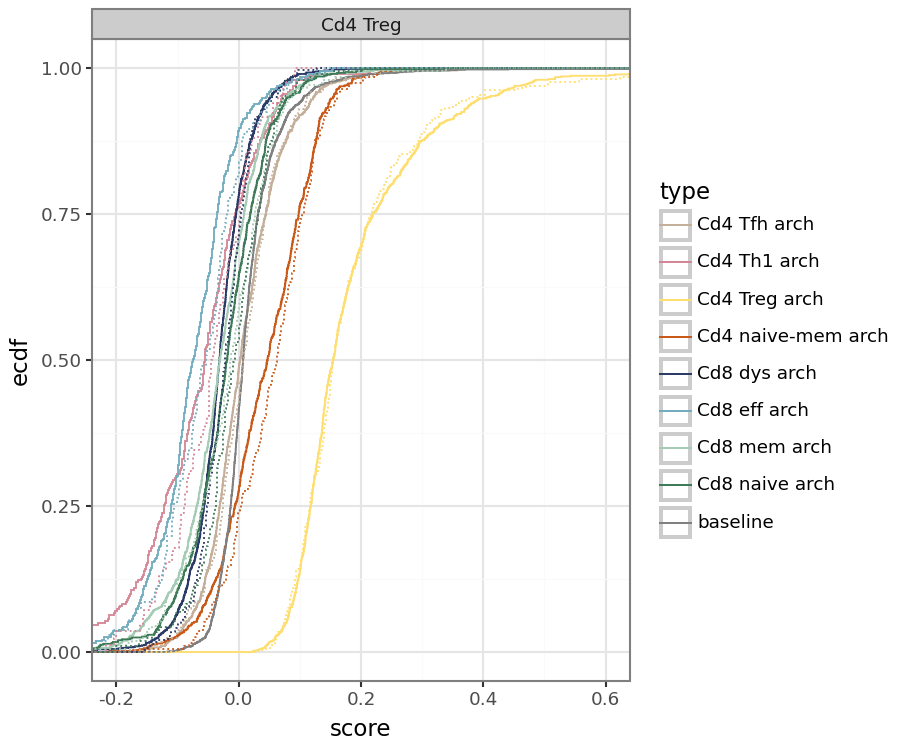

In [196]:
## plotting all archetypes
ggplot(filtered_final_score_plotting[filtered_final_score_plotting["cell_type"] == "Cd4 Treg"], aes(
    x="score", color = "type")) + stat_ecdf() + stat_ecdf(filtered_non_deg_plotting[filtered_non_deg_plotting[
    "cell_type"] == "Cd4 Treg"], linetype = "dotted") + theme_bw() + theme(dpi = 200, figure_size=(6, 5)) + \
facet_wrap("~ cell_type") + scale_color_manual(arch_colors_v2) + coord_cartesian(xlim = (-0.2, 0.6))

## look for archetypes with higher scores in each cell population

In [197]:
from scipy.stats import kstest
arch_vs_baseline_tests = pd.DataFrame()
for ct in filtered_final_score_plotting.cell_type.unique():
    for a in filtered_final_score_plotting["type"].unique():
        if a != "baseline":
            arch_scores = filtered_final_score_plotting[(filtered_final_score_plotting["cell_type"] == ct) & (
                filtered_final_score_plotting["type"] == a) & (filtered_final_score_plotting["sig +"])]["score"]
            baseline_scores = filtered_final_score_plotting[(filtered_final_score_plotting["cell_type"] == ct) & (
                filtered_final_score_plotting["type"] == "baseline") & (filtered_final_score_plotting["sig +"])][
                "score"]
            test_pval = kstest(arch_scores, baseline_scores, alternative="less")[1]
            arch_vs_baseline_tests = pd.concat([arch_vs_baseline_tests, pd.DataFrame({
                "cell_type": [ct], "arch": [a], "pval": [test_pval]})])
arch_vs_baseline_tests["sig"] = arch_vs_baseline_tests["pval"] <= 0.05/arch_vs_baseline_tests.shape[0]
arch_vs_baseline_tests[arch_vs_baseline_tests["sig"]]

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/scipy/stats/_stats_py.py:8380: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.


,cell_type,arch,pval,sig
0,Cd8 naïve,Cd8 naive arch,0.000000e+00,True
0,Cd8 naïve,Cd8 mem arch,1.245969e-95,True
0,Cd8 naïve,Cd4 naive-mem arch,3.600093e-158,True
0,Cd4 naïve,Cd8 naive arch,1.238355e-184,True
0,Cd4 naïve,Cd8 mem arch,1.536589e-07,True
0,Cd4 naïve,Cd4 naive-mem arch,0.000000e+00,True
0,Cd4 naïve,Cd4 Treg arch,1.578515e-36,True
0,Cd4 Tfh,Cd4 Tfh arch,0.000000e+00,True
0,Cd4 Tfh,Cd4 Treg arch,4.538703e-10,True
0,Cd8 dys,Cd8 dys arch,1.922688e-186,True


In [198]:
import statsmodels.stats.multitest  as mt

_, adj_p_values, _, _ = mt.multipletests(arch_vs_baseline_tests["pval"], method='fdr_bh')
arch_vs_baseline_tests["padj"] = adj_p_values

In [199]:
arch_vs_baseline_tests["sig"] = arch_vs_baseline_tests["padj"] <= 0.05

In [200]:
arch_vs_baseline_tests[(arch_vs_baseline_tests["sig"]) * (arch_vs_baseline_tests["cell_type"] == "Cd4 Tfh")]

,cell_type,arch,pval,sig,padj
0,Cd4 Tfh,Cd4 Tfh arch,0.000000e+00,True,0.000000e+00
0,Cd4 Tfh,Cd4 Treg arch,4.538703e-10,True,1.141160e-09


In [201]:
filtered_final_score_plotting[filtered_final_score_plotting["baseline"]]

,cell_type,score,type,gene,log2FC,cluster_means,noncluster_means,pval,padj,cluster,-log p,baseline,sig +
0,Cd8 naïve,0.359358,baseline,Slc6a19,5.391685,3423.7870,81.55384,0.000000e+00,0.000000e+00,Cd8 naïve,306.734857,True,True
3,Cd8 naïve,0.217005,baseline,Auts2,3.797046,1891.5233,136.07709,1.025971e-163,4.772318e-162,Cd8 naïve,161.321271,True,True
10,Cd8 naïve,0.163326,baseline,Rapgef4,3.505551,1692.4156,149.01482,7.717953e-135,2.154011e-133,Cd8 naïve,132.666752,True,True
16,Cd8 naïve,0.247878,baseline,Plaur,3.316070,2112.2732,212.08620,2.764316e-128,6.735278e-127,Cd8 naïve,126.171644,True,True
18,Cd8 naïve,0.318032,baseline,Sell,3.260108,15971.9020,1667.11770,0.000000e+00,0.000000e+00,Cd8 naïve,306.734857,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196706,Cd8 prog,-0.042184,baseline,Arhgap30,0.001473,3617.1013,3613.41000,1.142916e-02,2.884594e-02,Cd8 prog,1.539915,True,True
196714,Cd8 prog,-0.016857,baseline,Ccdc88b,0.001222,655.4064,654.85170,1.002013e-02,2.618502e-02,Cd8 prog,1.581947,True,True
196724,Cd8 prog,-0.008189,baseline,H13,0.001079,1960.0360,1958.57100,5.364776e-03,1.562004e-02,Cd8 prog,1.806318,True,True
196731,Cd8 prog,0.003229,baseline,Ndfip1,0.000760,6584.9790,6581.51030,2.086227e-04,1.043743e-03,Cd8 prog,2.981406,True,True


In [202]:
def plot_ct_scores(ct = None, deg_df = filtered_final_score_plotting, nondeg_df = filtered_non_deg_plotting):
    if ct is None:
        plot_df = pd.concat([arch_vs_baseline_tests[arch_vs_baseline_tests["sig"]].merge(deg_df, left_on = [
            "cell_type", "arch"], right_on = ["cell_type", "type"]), deg_df[(deg_df["baseline"])]])  
        other_plot_df = arch_vs_baseline_tests[arch_vs_baseline_tests["sig"]].merge(nondeg_df, left_on = [
            "cell_type", "arch"], right_on = ["cell_type", "type"])
    else:
        plot_df = pd.concat([arch_vs_baseline_tests[arch_vs_baseline_tests["sig"]].merge(deg_df[
            deg_df.cluster == ct], left_on = ["cell_type", "arch"], right_on = ["cell_type", "type"]),
                           deg_df[(deg_df["baseline"]) & (deg_df.cluster == ct)]])  
        other_plot_df = arch_vs_baseline_tests[arch_vs_baseline_tests["sig"]].merge(nondeg_df[
            nondeg_df.cluster == ct], left_on = ["cell_type", "arch"], right_on = ["cell_type", "type"])
    return ggplot(plot_df, aes(x="score", color = "type")) + stat_ecdf() + theme_bw() + stat_ecdf(
        other_plot_df, linetype = "dotted") + theme(dpi = 200, figure_size=(6, 5)) + facet_wrap(
        "~ cell_type") + scale_color_manual(arch_colors_v2) + coord_cartesian(xlim = (-0.2, 0.6))

In [203]:
filtered_final_score_plotting

,cell_type,score,type,gene,log2FC,cluster_means,noncluster_means,pval,padj,cluster,-log p,baseline,sig +
0,Cd8 naïve,0.359358,baseline,Slc6a19,5.391685,3423.7870,81.55384,0.000000e+00,0.000000e+00,Cd8 naïve,306.734857,True,True
1,Cd8 naïve,0.388327,Cd8 naive arch,Slc6a19,5.391685,3423.7870,81.55384,0.000000e+00,0.000000e+00,Cd8 naïve,306.734857,False,True
2,Cd8 naïve,-0.017244,Cd4 Tfh arch,Slc6a19,5.391685,3423.7870,81.55384,0.000000e+00,0.000000e+00,Cd8 naïve,306.734857,False,True
3,Cd8 naïve,0.217005,baseline,Auts2,3.797046,1891.5233,136.07709,1.025971e-163,4.772318e-162,Cd8 naïve,161.321271,True,True
4,Cd8 naïve,0.269068,Cd8 mem arch,Auts2,3.797046,1891.5233,136.07709,1.025971e-163,4.772318e-162,Cd8 naïve,161.321271,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196736,Cd8 prog,0.054221,Cd4 Tfh arch,Ndfip1,0.000760,6584.9790,6581.51030,2.086227e-04,1.043743e-03,Cd8 prog,2.981406,False,True
196737,Cd8 prog,-0.093423,Cd4 naive-mem arch,Ndfip1,0.000760,6584.9790,6581.51030,2.086227e-04,1.043743e-03,Cd8 prog,2.981406,False,True
196738,Cd8 prog,-0.004340,Cd4 Treg arch,Ndfip1,0.000760,6584.9790,6581.51030,2.086227e-04,1.043743e-03,Cd8 prog,2.981406,False,True
196753,Cd8 prog,-0.031198,baseline,Atp6v0e,0.000125,4736.2383,4735.82800,3.676611e-03,1.162351e-02,Cd8 prog,1.934663,True,True


## main panel F

In [209]:
cd4_tfh_plots = plot_ct_scores("Cd4 Tfh")
cd4_tfh_plots
ggsave(cd4_tfh_plots, "figures/fig3_panel_f.pdf")

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 6 x 5 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/fig3_panel_f.pdf


/tmp/ipykernel_4057111/57586844.py:1: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


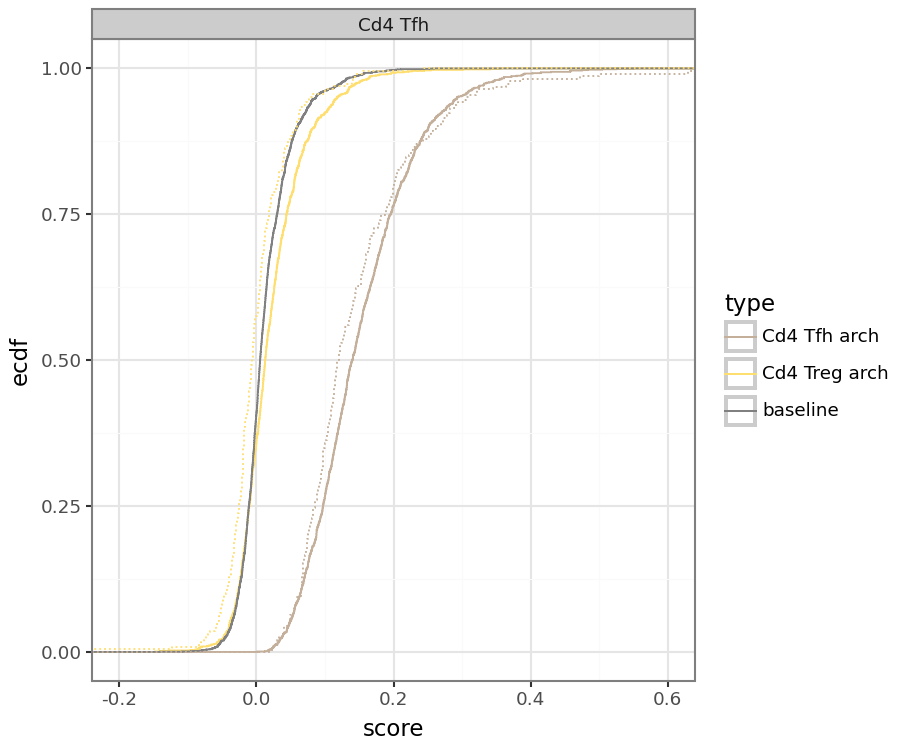

In [265]:
print(cd4_tfh_plots)

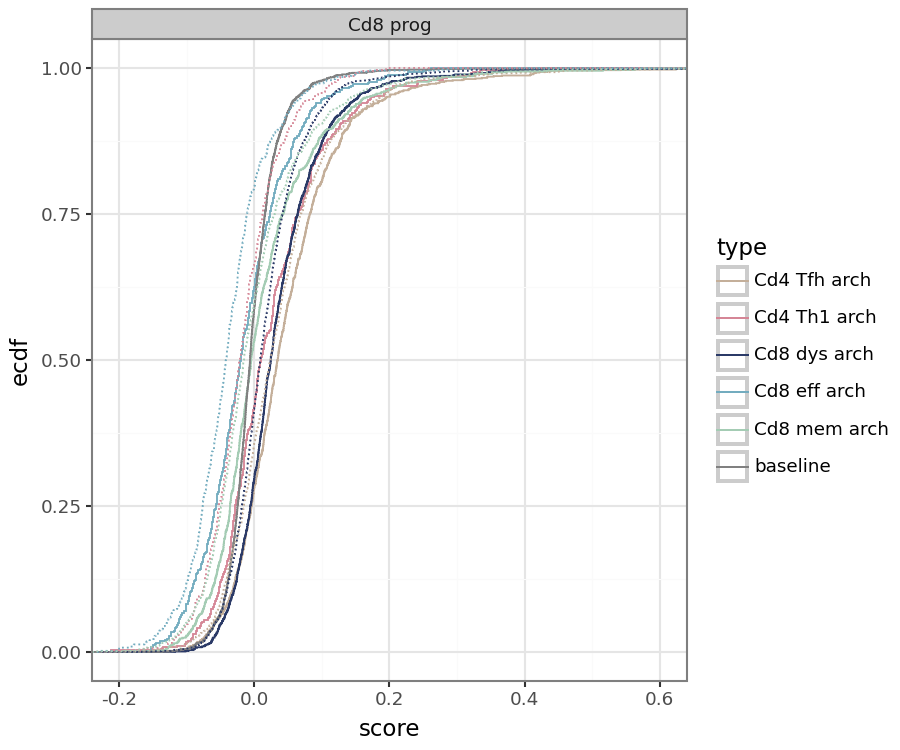

In [206]:
plot_ct_scores("Cd8 prog")

## supplementary panel F

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 9 x 6 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/sfig3_e.png


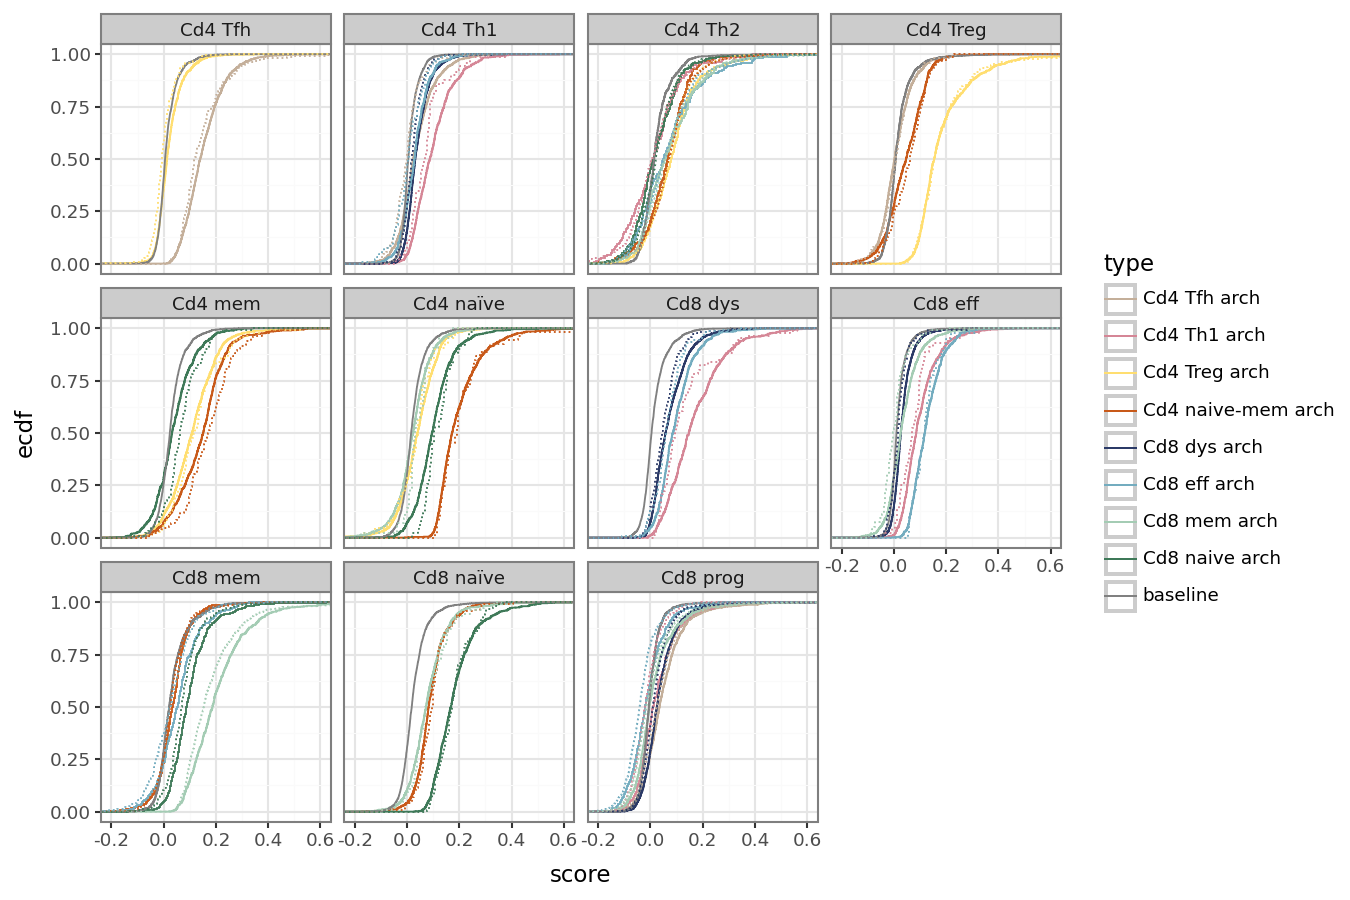

In [212]:
all_cts_plot = plot_ct_scores() + theme(figure_size=(9, 6))
ggsave(all_cts_plot, "figures/sfig3_e.png")
all_cts_plot

## Panel G

In [227]:
from scipy.stats import spearmanr
def make_uniq_zscored_gene_archs(g, arch_df):
    res = pd.DataFrame()
    for a in list(arch_df[arch_df["gene"] == g]["best arch"].unique()) + ["baseline"]:
        print(a)
        peaks = arch_df[(arch_df["gene"] == g) & (arch_df["best arch"] == a)].index
        if a == "baseline":
            peaks = peak_ad.var_names[peak_ad.var.gene == g]
        
        for cl in peak_ad.obs["final annotation"].unique():
            gene_i =  np.where(rna.var_names == g)[0]
            cell_is = np.where(rna.obs["final annotation"] == cl)[0]
            for p in peaks:
                peak_i = np.where(peak_ad.var_names == p)[0]
                corr = spearmanr(zscored_peaks[cell_is, peak_i].flatten(), 
                                 rna[cell_is, gene_i].layers["theta_10"].flatten())
                res = pd.concat([res, pd.DataFrame({"arch": [a], "gene": [g], "peak": [p], "rho": [corr[0]],
                                                    "pval": [corr[1]], "cluster": cl})])
    _, adj_p_values, _, _ = mt.multipletests(res["pval"], method='fdr_bh')
    res["padj"] = adj_p_values
    res["sig"] = res["padj"] <= 0.05
    return res
    

In [228]:
def plot_gene_archs(g, corr_df, filtered_by_degs = False): # , corr_df = gene_peak_arch_corrs):
    df = corr_df[corr_df["gene"] == g]
    df["color"] = [row["arch"] if row["sig"] else "NA" for _, row in df.iterrows()]
    # print(df.color.values[-1])
    if filtered_by_degs:
        df = df[df.cluster.isin(degs[(degs.gene  == g) & (degs["log2FC"] > 0.5)]["cluster"])]
    return ggplot(df, aes(y="rho", x="arch", color = "arch")) + theme_bw() + labs(title = g) + theme(
        dpi = 200, legend_position = "none") + scale_color_manual(arch_colors_v2)+  geom_jitter(aes(
        fill = "color"), width = 0.1, height = 0) + facet_wrap("~ cluster", scales = "fixed") + geom_vline(
        xintercept = 0,linetype = "dotted", color = "gray")  + scale_fill_manual(arch_colors_v3) + coord_flip()

In [229]:
arch_colors = {"Cd8 naive arch": "#3E7958",
               "Cd8 mem arch": "#A4CCB4",
               "Cd4 Tfh arch": "#C4AF9A",
               "Cd8 dys arch": "#2B3A67",
               "Cd4 Th1 arch": "#D58696",
               "Cd8 eff arch": "#73ACBF",
               "Cd4 Treg arch": "#FFDE70",
               "Cd4 naive-mem arch": "#C85919"}
arch_colors_v2 = arch_colors.copy()
arch_colors_v2["baseline"] = "gray"

In [231]:
genes_for_archs = ["Tox", "Msi2", "Ets1"]
res = pd.concat([make_uniq_zscored_gene_archs(g, thresholded_arches) for g in genes_for_archs])

Cd4 Treg arch
Cd4 Tfh arch
Cd8 dys arch
Cd4 Th1 arch
Cd8 naive arch
baseline
Cd8 dys arch
Cd4 Tfh arch
Cd8 naive arch
Cd4 Treg arch
Cd4 naive-mem arch
Cd4 Th1 arch
baseline
Cd4 Tfh arch
Cd8 dys arch
Cd4 Treg arch
Cd4 naive-mem arch
Cd8 naive arch
Cd4 Th1 arch
Cd8 mem arch
Cd8 eff arch
baseline


In [235]:
arch_colors_v3 = arch_colors_v2.copy()
arch_colors_v3["NA"]= "white"

/tmp/ipykernel_4057111/510016549.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_4057111/496087361.py:4: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


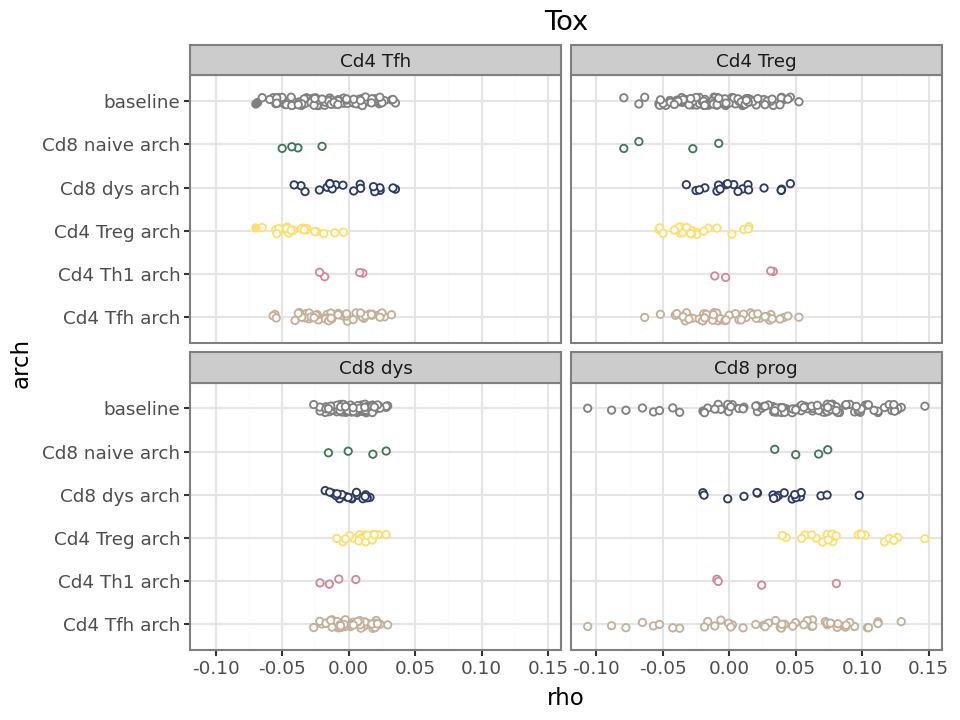

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/3g_Tox.pdf
/tmp/ipykernel_4057111/510016549.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_4057111/496087361.py:4: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


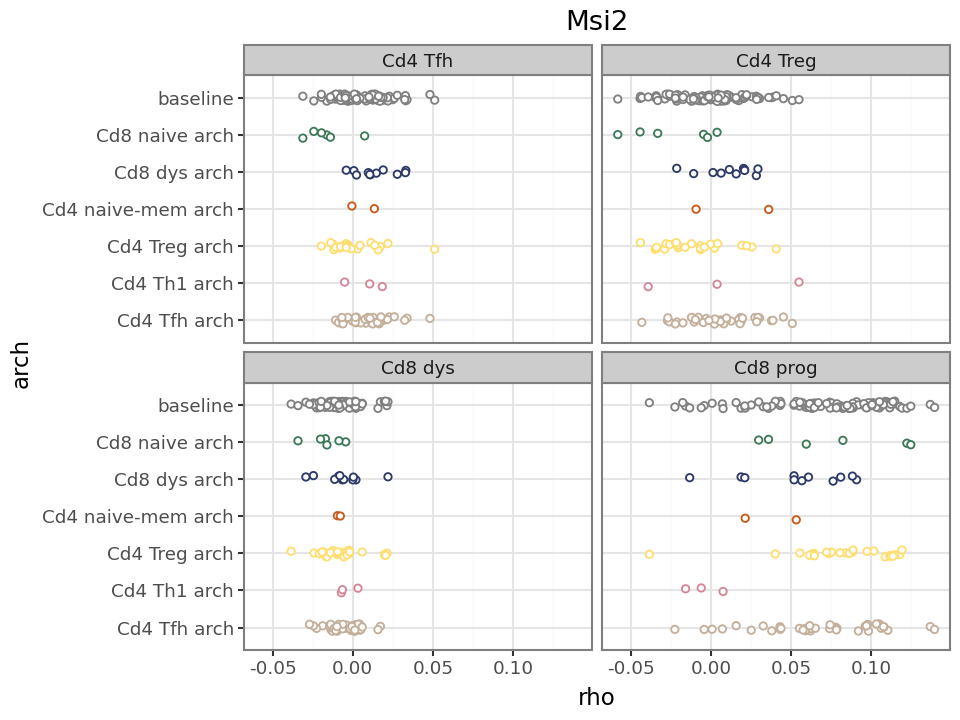

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/3g_Msi2.pdf


/tmp/ipykernel_4057111/510016549.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_4057111/496087361.py:4: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


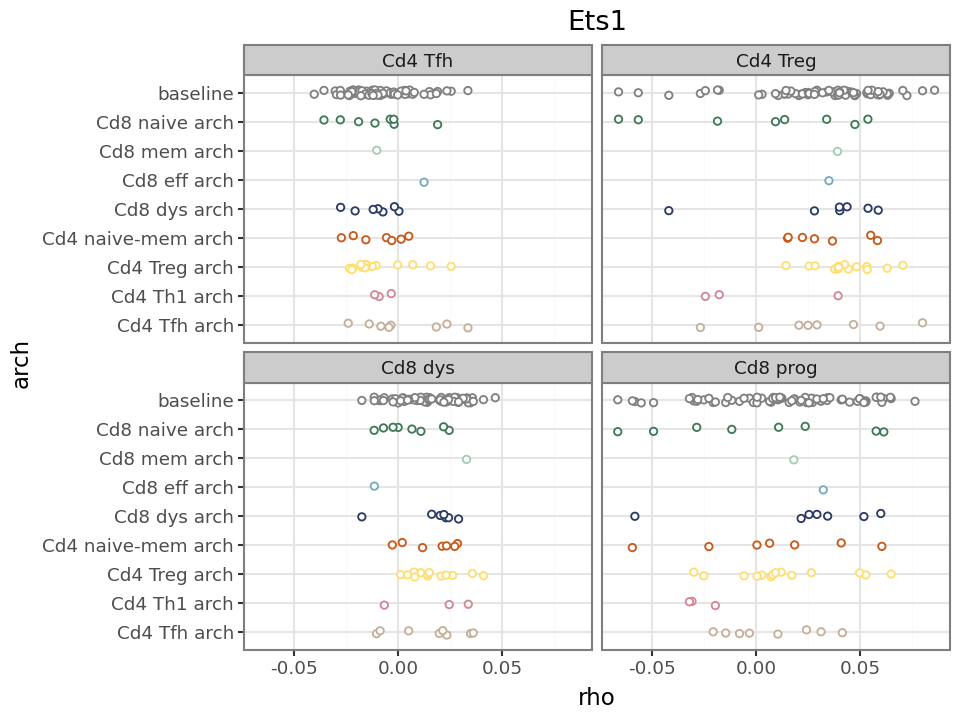

/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:604: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Genomics/argo/users/skwalker/scvi_feb2023/lib/python3.9/site-packages/plotnine/ggplot.py:605: PlotnineWarning: Filename: figures/3g_Ets1.pdf


In [238]:
for g in genes_for_archs:
    p = plot_gene_archs(g, res[res["cluster"].isin(["Cd8 prog", "Cd4 Tfh", "Cd4 Treg", "Cd8 dys"])]) + labs(
        title = g)
    print(p)
    ggsave(p, "figures/3g_%s.pdf"%g)